# July 1 Dipper Extinction-Corrected Color-Plane Clustering

This notebook compares the candidate partitions produced by every applicable sample-clustering estimator exposed by `sklearn.cluster` in the MALCA environment. The four **foreground-extinction-corrected** color planes are analyzed **separately**:

1. $(W1-W2)_0$ versus $(H-K_s)_0$
2. $(W1-W2)_0$ versus $(W2-W3)_0$
3. $(W1-W2)_0$ versus $(W1-W4)_0$
4. $(K_s-W4)_0$ versus $(K_s-W3)_0$, with the existing empirical disk-stage boundaries overlaid

The correction uses the stored line-of-sight $A_V^{3D}$ and the project's $R_V=3.1$ band coefficients through `malca.plotting.extinction`. It removes estimated foreground extinction only; it does not remove source-local or circumstellar extinction. Missing or negative $A_V^{3D}$ values follow the project convention of zero correction, and uncertainty in $A_V^{3D}$ is not propagated.

The notebook reads the live dipper labels from the July 1 Review database and uses the same stored-photometry loading and corrected-color definitions as `scripts/plot_dipper_colors.py`. No remote catalog queries or photometric imputations are performed. Cluster labels are descriptive partitions, not physical classes.

## Method boundary

Included sample-clustering estimators:

- `AffinityPropagation`
- `AgglomerativeClustering`
- `Birch`
- `BisectingKMeans`
- `DBSCAN`
- `HDBSCAN`
- `KMeans`
- `MeanShift`
- `MiniBatchKMeans`
- `OPTICS`
- `SpectralClustering`

`FeatureAgglomeration` is excluded because it clusters columns rather than candidates. `SpectralBiclustering` and `SpectralCoclustering` are excluded because they co-cluster matrix rows and columns and require a different scientific data model. Function-level APIs such as `dbscan`, `mean_shift`, and `k_means` implement the same algorithms as the included estimators and are not counted as additional methods.

Foreground dereddening is applied first; each corrected plane is then complete-case filtered and standardized independently. The benchmark searches a compact, data-driven parameter grid. Internal scores are exploratory diagnostics: they do not establish that an astrophysically meaningful clustering exists.

In [1]:
from __future__ import annotations

import ast
import json
import math
import sqlite3
import sys
import time
import warnings
from dataclasses import dataclass
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.cluster import (
    AffinityPropagation,
    AgglomerativeClustering,
    Birch,
    BisectingKMeans,
    DBSCAN,
    HDBSCAN,
    KMeans,
    MeanShift,
    MiniBatchKMeans,
    OPTICS,
    SpectralClustering,
    estimate_bandwidth,
)
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    normalized_mutual_info_score,
    pairwise_distances,
    silhouette_score,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

from malca.plotting.color_color_labels import LABEL_KS_W3_0, LABEL_KS_W4_0
from malca.plotting.extinction import IR_AV_COEFFICIENTS

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 220)

RUN_NAME = "dat3-full-extended_2026-07-01-v4"
RANDOM_STATE = 42
MAX_K = 8
STABILITY_REPEATS = 20
PERTURBATION_SIGMA = 0.03  # in standardized-coordinate units
WRITE_OUTPUTS = True

root_candidates = [Path.cwd(), *Path.cwd().parents]
REPO_ROOT = next(
    (
        p
        for p in root_candidates
        if (p / "malca").is_dir()
        and (p / "output" / "runs" / RUN_NAME / "review" / "review.db").exists()
    ),
    Path.cwd(),
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

RUN_DIR = REPO_ROOT / "output" / "runs" / RUN_NAME
DB_PATH = RUN_DIR / "review" / "review.db"
RESULTS_DIR = RUN_DIR / "results"
OUTPUT_DIR = RESULTS_DIR / "dipper_color_plane_clustering"

print(f"scikit-learn = {sklearn.__version__}")
print(f"REPO_ROOT     = {REPO_ROOT}")
print(f"RUN_DIR       = {RUN_DIR}")
print(f"DB_PATH       = {DB_PATH}")
print(f"OUTPUT_DIR    = {OUTPUT_DIR}")

scikit-learn = 1.7.2
REPO_ROOT     = /Users/calder/code/malca
RUN_DIR       = /Users/calder/code/malca/output/runs/dat3-full-extended_2026-07-01-v4
DB_PATH       = /Users/calder/code/malca/output/runs/dat3-full-extended_2026-07-01-v4/review/review.db
OUTPUT_DIR    = /Users/calder/code/malca/output/runs/dat3-full-extended_2026-07-01-v4/results/dipper_color_plane_clustering


## Load the live dipper population

The private helpers below are deliberately reused from the publication color workflow so this notebook does not introduce a second definition of the colors. `refresh_missing=False` guarantees that the notebook uses stored data only.

In [2]:
from scripts import plot_dipper_colors as color_workflow

workflow_args = SimpleNamespace(
    run_root=RUN_DIR,
    review_db=DB_PATH,
    labels_csv=None,
    sed_photometry=None,
    sed_excess_summary=None,
    refresh_missing_catalog=False,
)
color_workflow._configure_paths(workflow_args)

dippers = color_workflow._load_dipper_payloads()
dippers = color_workflow._refresh_catalog_photometry(dippers, refresh_missing=False)
dippers = color_workflow._compute_colors(dippers)

DEREDDENED_FEATURES = [
    "w1_w2_0", "H_K_0", "w2_w3_0", "w1_w4_0",
    "tmass_k_0", "w3_0", "w4_0",
]
missing_dereddened = [column for column in DEREDDENED_FEATURES if column not in dippers.columns]
assert not missing_dereddened, f"Missing corrected-color inputs: {missing_dereddened}"

av = pd.to_numeric(dippers["A_v_3d"], errors="coerce")
extinction_metadata = {
    "color_basis": "foreground_extinction_corrected",
    "av_column": "A_v_3d",
    "extinction_law": "project R_V=3.1 band coefficients",
    "band_av_coefficients": IR_AV_COEFFICIENTS,
    "missing_or_negative_av_policy": "zero correction",
    "av_uncertainty_propagated": False,
    "n_dippers": int(len(dippers)),
    "n_finite_av": int(np.isfinite(av).sum()),
    "n_nonnegative_av": int((av >= 0).sum()),
    "n_positive_av": int((av > 0).sum()),
    "av_min": float(av.min()),
    "av_median": float(av.median()),
    "av_max": float(av.max()),
}
print(
    "Foreground dereddening: "
    f"finite A_V^3D={extinction_metadata['n_finite_av']}/{len(dippers)}, "
    f"nonnegative={extinction_metadata['n_nonnegative_av']}/{len(dippers)}"
)
display(
    pd.DataFrame(
        [{"band": band, "A_lambda/A_V": coefficient} for band, coefficient in IR_AV_COEFFICIENTS.items()]
    )
)

with sqlite3.connect(f"file:{DB_PATH}?mode=ro", uri=True) as conn:
    live_dipper_ids = {
        str(row[0])
        for row in conn.execute(
            "SELECT candidate_id FROM reviews WHERE event_class = 'dipper'"
        )
    }

loaded_ids = set(dippers["candidate_id"].astype(str))
assert loaded_ids == live_dipper_ids, (
    f"Loaded/live dipper mismatch: {len(loaded_ids)} loaded versus "
    f"{len(live_dipper_ids)} live; missing={sorted(live_dipper_ids - loaded_ids)[:10]}"
)
print(f"Loaded {len(dippers):,} live dippers from Review.")

Run root: /Users/calder/code/malca/output/runs/dat3-full-extended_2026-07-01-v4
Review DB: /Users/calder/code/malca/output/runs/dat3-full-extended_2026-07-01-v4/review/review.db
Labels: reviews.event_class
SED photometry: /Users/calder/code/malca/output/runs/dat3-full-extended_2026-07-01-v4/results/sed_photometry.parquet
SED-excess summary: /Users/calder/code/malca/output/runs/dat3-full-extended_2026-07-01-v4/results/marked_dipper_seds/marked_dipper_sed_excess_summary.csv
Results directory: /Users/calder/code/malca/output/runs/dat3-full-extended_2026-07-01-v4/results
Loaded 182 labeled dippers from /Users/calder/code/malca/output/runs/dat3-full-extended_2026-07-01-v4/review/review.db:reviews
Loaded structured candidate data: coordinates=182/182, W1-W2=176/182, W1-W4=176/182
Catalog refresh coordinate rows: 182/182
Using stored catalog photometry; missing-catalog refresh disabled.
Foreground dereddening: finite A_V^3D=182/182, nonnegative=182/182


,band,A_lambda/A_V
0,tmass_h,0.175
1,tmass_k,0.112
2,w1,0.061
3,w2,0.047
4,w3,0.000
5,w4,0.000


Loaded 182 live dippers from Review.


## Existing empirical $K_s-W4$ versus $K_s-W3$ regions

The fourth plane uses observed colors $x=K_s-W4$ and $y=K_s-W3$. Its boundary vertices and label locations are loaded directly from `scripts/plot_july1_dipper_disk_color_color.py`, rather than being copied into a second independent definition. That workflow describes them as figure-style boundaries digitized from the supplied 2MASS–WISE disk diagram, with Diskless, Debris, Evolved, Full, and Transition regions. They are comparison guides—not labels used to fit the clustering algorithms.

In [3]:
DISK_BOUNDARY_SOURCE = REPO_ROOT / "scripts" / "plot_july1_dipper_disk_color_color.py"


def load_literal_assignments(path: Path, names: set[str]) -> dict:
    tree = ast.parse(path.read_text(encoding="utf-8"), filename=str(path))
    values = {}
    for node in tree.body:
        if not isinstance(node, ast.Assign) or len(node.targets) != 1:
            continue
        target = node.targets[0]
        if isinstance(target, ast.Name) and target.id in names:
            values[target.id] = ast.literal_eval(node.value)
    missing = names - set(values)
    if missing:
        raise RuntimeError(f"Missing literal boundary definitions in {path}: {sorted(missing)}")
    return values


disk_literals = load_literal_assignments(
    DISK_BOUNDARY_SOURCE,
    {"BOUNDARY_SEGMENTS", "REGION_LABELS", "REGION_ORDER"},
)
DISK_BOUNDARY_SEGMENTS = disk_literals["BOUNDARY_SEGMENTS"]
DISK_REGION_LABELS = disk_literals["REGION_LABELS"]
DISK_REGION_ORDER = tuple(disk_literals["REGION_ORDER"])

dippers["ks_w3_0"] = pd.to_numeric(dippers["tmass_k_0"], errors="coerce") - pd.to_numeric(dippers["w3_0"], errors="coerce")
dippers["ks_w4_0"] = pd.to_numeric(dippers["tmass_k_0"], errors="coerce") - pd.to_numeric(dippers["w4_0"], errors="coerce")
dippers["ks_w3_err"] = np.hypot(
    pd.to_numeric(dippers["tmass_k_err"], errors="coerce"),
    pd.to_numeric(dippers["w3_err"], errors="coerce"),
)
dippers["ks_w4_err"] = np.hypot(
    pd.to_numeric(dippers["tmass_k_err"], errors="coerce"),
    pd.to_numeric(dippers["w4_err"], errors="coerce"),
)


def _line_side(x0: float, y0: float, x1: float, y1: float, x: float, y: float) -> float:
    return (x1 - x0) * (y - y0) - (y1 - y0) * (x - x0)


def classify_empirical_disk_region(ks_w4: float, ks_w3: float) -> str:
    x = float(ks_w4)
    y = float(ks_w3)
    diskless_debris = DISK_BOUNDARY_SEGMENTS["diskless_debris"]
    debris_evolved = DISK_BOUNDARY_SEGMENTS["debris_evolved"]
    evolved_full = DISK_BOUNDARY_SEGMENTS["evolved_full"]
    evolved_transition = DISK_BOUNDARY_SEGMENTS["evolved_transition"]
    s_diskless_debris = _line_side(*diskless_debris[0], *diskless_debris[1], x, y)
    s_debris_evolved = _line_side(*debris_evolved[0], *debris_evolved[1], x, y)
    s_evolved_transition = _line_side(*evolved_transition[0], *evolved_transition[1], x, y)
    s_upper = (
        _line_side(*evolved_full[0], *evolved_full[1], x, y)
        if x <= evolved_full[1][0]
        else _line_side(*evolved_full[1], *evolved_full[2], x, y)
    )
    if s_upper > 0:
        return "Full" if s_evolved_transition > 0 else "Transition"
    if s_diskless_debris < 0:
        return "Diskless"
    if s_debris_evolved < 0:
        return "Debris"
    return "Evolved"


dippers["disk_region"] = [
    classify_empirical_disk_region(x, y) if np.isfinite(x) and np.isfinite(y) else np.nan
    for x, y in zip(dippers["ks_w4_0"], dippers["ks_w3_0"])
]


def draw_empirical_disk_boundaries(ax: plt.Axes, *, include_region_labels: bool) -> None:
    for points in DISK_BOUNDARY_SEGMENTS.values():
        xs, ys = zip(*points)
        ax.plot(
            xs,
            ys,
            color="black",
            linestyle=(0, (5, 2.5)),
            linewidth=1.4,
            solid_capstyle="butt",
            dash_capstyle="butt",
            zorder=8,
        )
    if include_region_labels:
        for label, (x, y) in DISK_REGION_LABELS.items():
            ax.text(x, y, label, fontsize=10, ha="left", va="center", color="black", zorder=9)
    ax.set_xlim(-0.5, 6.8)
    ax.set_ylim(-0.75, 4.6)


boundary_rows = [
    {"segment": segment, "vertex_index": i, "ks_w4_0": x, "ks_w3_0": y}
    for segment, points in DISK_BOUNDARY_SEGMENTS.items()
    for i, (x, y) in enumerate(points)
]
disk_boundary_table = pd.DataFrame(boundary_rows)
print(f"Loaded empirical boundaries from {DISK_BOUNDARY_SOURCE}")
display(disk_boundary_table)
display(dippers["disk_region"].value_counts(dropna=False).rename_axis("empirical_region").reset_index(name="n"))

Loaded empirical boundaries from /Users/calder/code/malca/scripts/plot_july1_dipper_disk_color_color.py


,segment,vertex_index,ks_w4_0,ks_w3_0
0,diskless_debris,0,0.00,0.50
1,diskless_debris,1,0.42,-0.32
2,debris_evolved,0,1.50,1.25
3,debris_evolved,1,2.40,-0.25
4,evolved_full,0,2.50,2.50
5,evolved_full,1,3.50,1.50
6,evolved_full,2,5.00,0.00
7,evolved_transition,0,3.50,1.50
8,evolved_transition,1,6.55,2.70


,empirical_region,n
0,Evolved,59
1,Full,55
2,Debris,50
3,Diskless,8
4,NaN,7
5,Transition,3


,space,color_basis,features,n_complete,n_missing,coverage_fraction,n_unique_coordinate_pairs
0,wise_hk,foreground_extinction_corrected,"w1_w2_0, H_K_0",175,7,96.2%,175
1,wise_w1w2_w2w3,foreground_extinction_corrected,"w1_w2_0, w2_w3_0",176,6,96.7%,176
2,wise_w1w2_w1w4,foreground_extinction_corrected,"w1_w2_0, w1_w4_0",176,6,96.7%,176
3,disk_ks_w4_ks_w3,foreground_extinction_corrected,"ks_w4_0, ks_w3_0",175,7,96.2%,175


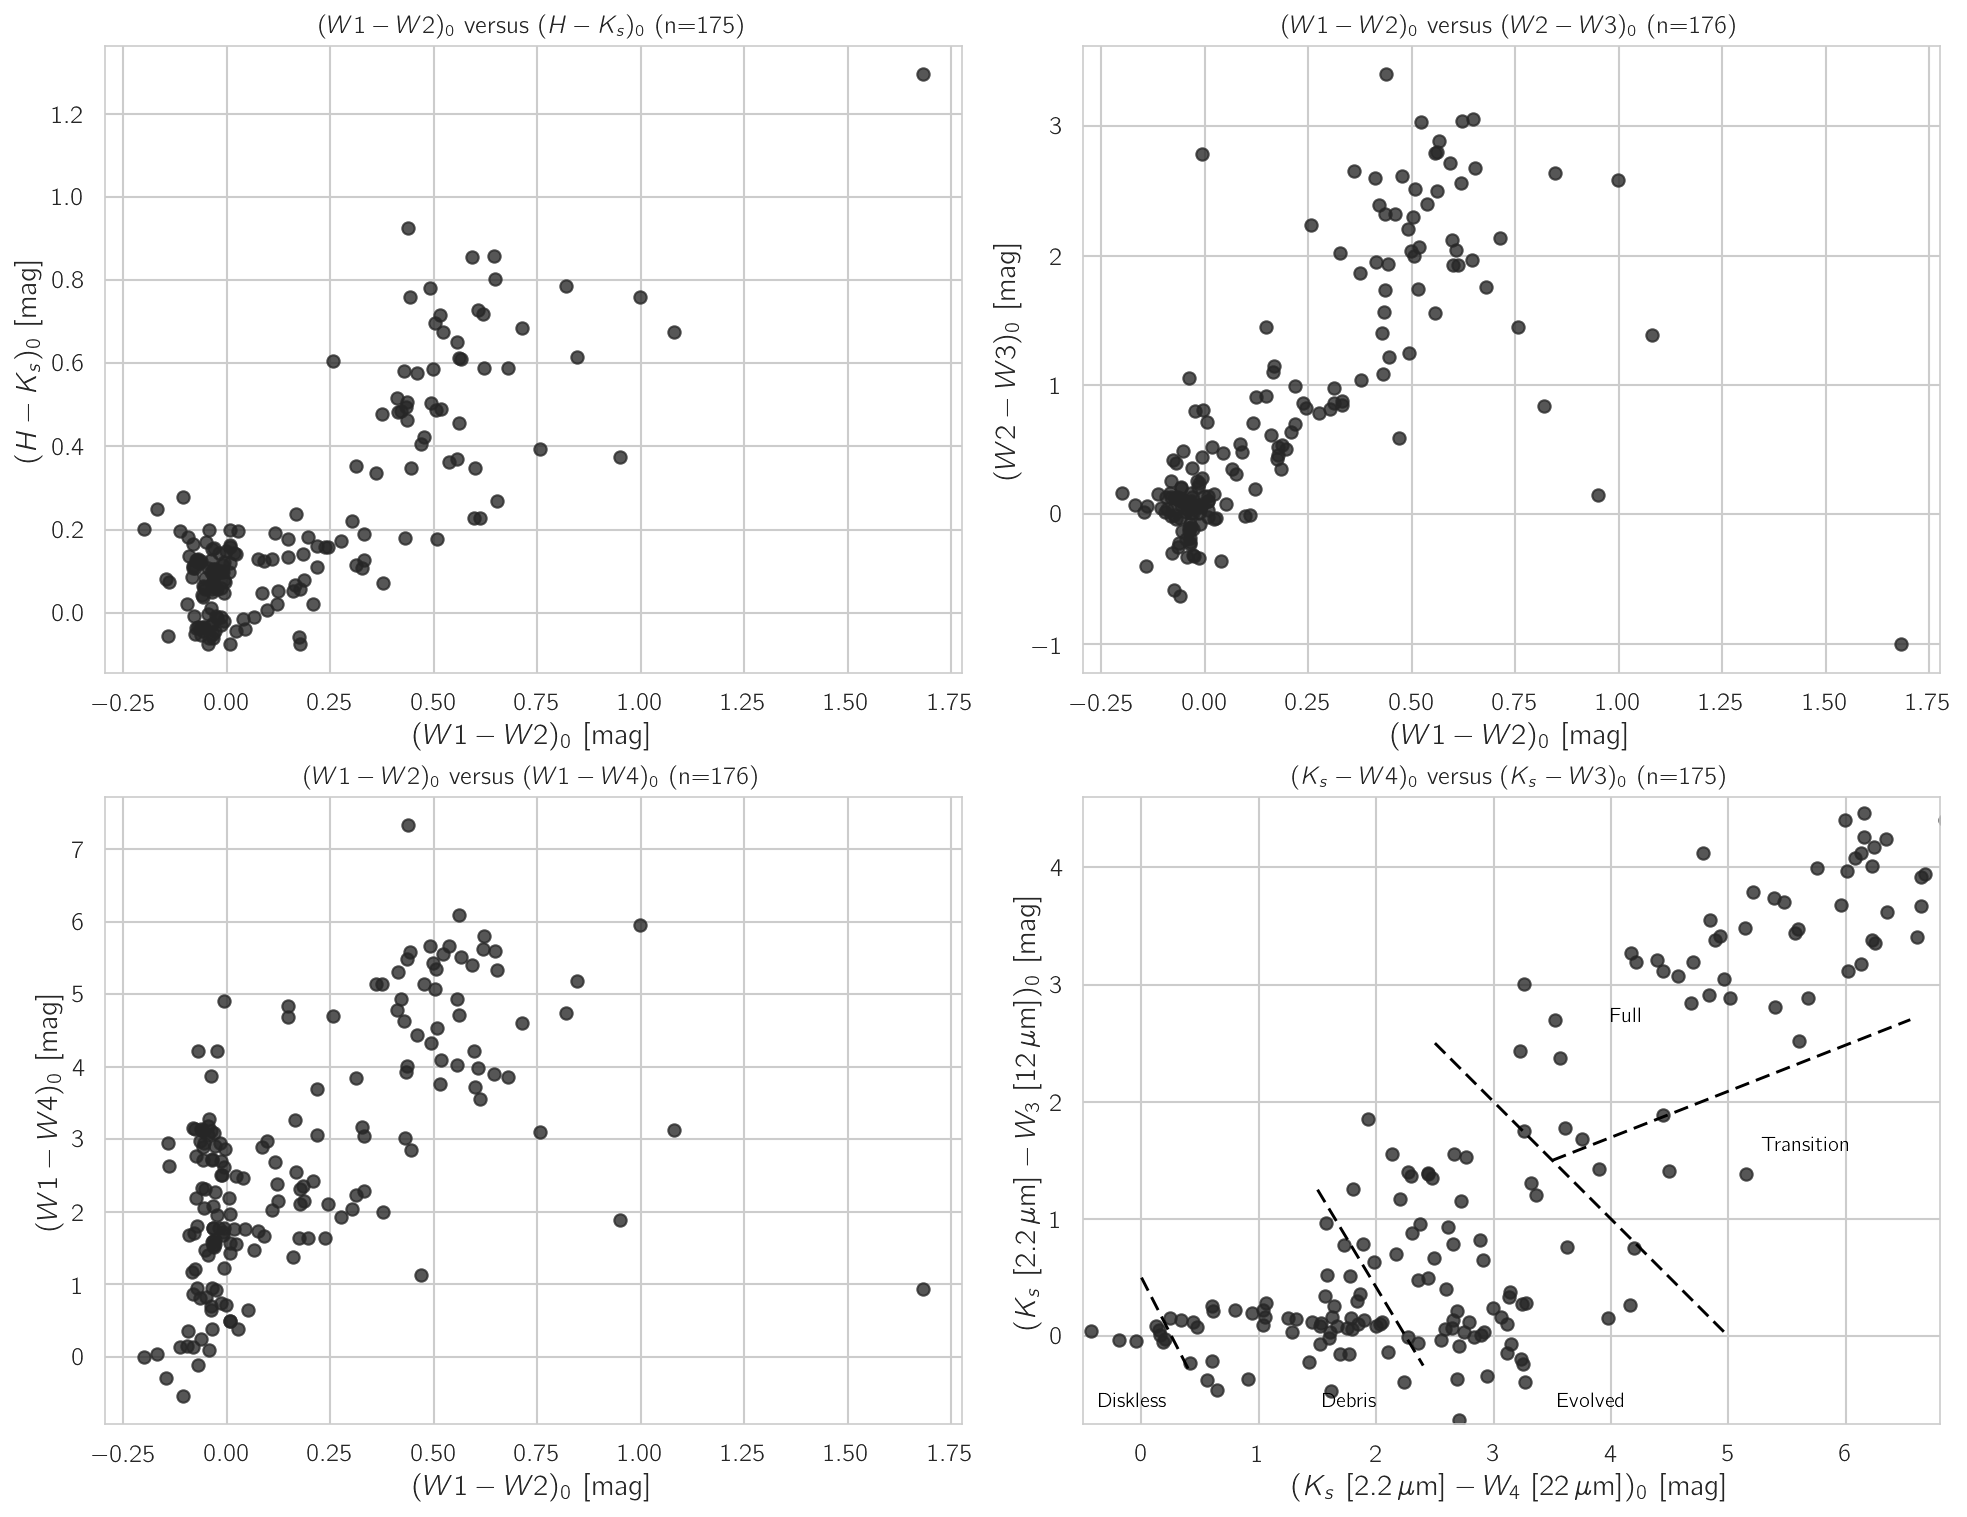

In [4]:
SPACE_CONFIG = {
    "wise_hk": {
        "features": ["w1_w2_0", "H_K_0"],
        "xlabel": r"$(W1-W2)_0$ [mag]",
        "ylabel": r"$(H-K_s)_0$ [mag]",
        "title": r"$(W1-W2)_0$ versus $(H-K_s)_0$",
    },
    "wise_w1w2_w2w3": {
        "features": ["w1_w2_0", "w2_w3_0"],
        "xlabel": r"$(W1-W2)_0$ [mag]",
        "ylabel": r"$(W2-W3)_0$ [mag]",
        "title": r"$(W1-W2)_0$ versus $(W2-W3)_0$",
    },
    "wise_w1w2_w1w4": {
        "features": ["w1_w2_0", "w1_w4_0"],
        "xlabel": r"$(W1-W2)_0$ [mag]",
        "ylabel": r"$(W1-W4)_0$ [mag]",
        "title": r"$(W1-W2)_0$ versus $(W1-W4)_0$",
    },
    "disk_ks_w4_ks_w3": {
        "features": ["ks_w4_0", "ks_w3_0"],
        "metadata_columns": ["disk_region", "ks_w4_err", "ks_w3_err"],
        "xlabel": LABEL_KS_W4_0,
        "ylabel": LABEL_KS_W3_0,
        "title": r"$(K_s-W4)_0$ versus $(K_s-W3)_0$",
        "empirical_disk_boundaries": True,
    },
}

space_data = {}
coverage_rows = []
for space_name, cfg in SPACE_CONFIG.items():
    features = cfg["features"]
    metadata_columns = cfg.get("metadata_columns", [])
    numeric = dippers[features].apply(pd.to_numeric, errors="coerce")
    finite = np.isfinite(numeric).all(axis=1)
    frame = dippers.loc[finite, ["candidate_id", *features, *metadata_columns]].copy().reset_index(drop=True)
    X_raw = frame[features].to_numpy(dtype=float)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)
    space_data[space_name] = {
        "frame": frame,
        "X_raw": X_raw,
        "X_scaled": X_scaled,
        "scaler": scaler,
    }
    coverage_rows.append(
        {
            "space": space_name,
            "color_basis": "foreground_extinction_corrected",
            "features": ", ".join(features),
            "n_complete": len(frame),
            "n_missing": len(dippers) - len(frame),
            "coverage_fraction": len(frame) / len(dippers),
            "n_unique_coordinate_pairs": len(np.unique(X_raw, axis=0)),
        }
    )

coverage = pd.DataFrame(coverage_rows)
display(coverage.style.format({"coverage_fraction": "{:.1%}"}))

fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)
for ax, (space_name, cfg) in zip(axes.flat, SPACE_CONFIG.items()):
    frame = space_data[space_name]["frame"]
    x, y = cfg["features"]
    ax.scatter(frame[x], frame[y], s=35, color="0.15", alpha=0.78)
    if cfg.get("empirical_disk_boundaries", False):
        draw_empirical_disk_boundaries(ax, include_region_labels=True)
    ax.set(xlabel=cfg["xlabel"], ylabel=cfg["ylabel"], title=f"{cfg['title']} (n={len(frame)})")
plt.show()

## Parameter grids and scoring

For fixed-$k$ methods, $k=2,\ldots,8$ (bounded by sample size). Density scales are derived from each plane's standardized nearest-neighbor distances. Affinity-propagation preferences are derived from the plane's pairwise similarities, and Mean Shift bandwidths are estimated from the plane itself.

Silhouette, Calinski–Harabasz, and Davies–Bouldin scores are calculated on non-noise members. A configuration is selection-eligible when it has at least two non-singleton clusters and no more than 35% noise. The eligibility threshold prevents a tiny high-silhouette subset from winning after labeling most candidates as noise. Noise remains a scientifically legitimate result and is retained in all output tables.

In [5]:
@dataclass(frozen=True)
class ModelSpec:
    spec_id: str
    method: str
    params: dict
    estimator: object


def _unique_positive(values, *, minimum=1e-4):
    return sorted({round(float(v), 6) for v in values if np.isfinite(v) and v > minimum})


def build_model_specs(X: np.ndarray, *, random_state: int = RANDOM_STATE) -> list[ModelSpec]:
    n = len(X)
    k_values = list(range(2, min(MAX_K, n - 1) + 1))
    specs: list[tuple[str, dict, object]] = []

    for k in k_values:
        specs.extend(
            [
                ("KMeans", {"n_clusters": k}, KMeans(n_clusters=k, n_init=20, random_state=random_state)),
                ("MiniBatchKMeans", {"n_clusters": k}, MiniBatchKMeans(n_clusters=k, n_init=20, batch_size=min(256, n), random_state=random_state)),
                ("BisectingKMeans", {"n_clusters": k}, BisectingKMeans(n_clusters=k, n_init=10, random_state=random_state)),
            ]
        )
        for linkage in ["ward", "complete", "average", "single"]:
            specs.append(
                (
                    "AgglomerativeClustering",
                    {"n_clusters": k, "linkage": linkage},
                    AgglomerativeClustering(n_clusters=k, linkage=linkage),
                )
            )
        for threshold in [0.25, 0.5, 0.75]:
            specs.append(
                (
                    "Birch",
                    {"n_clusters": k, "threshold": threshold},
                    Birch(n_clusters=k, threshold=threshold),
                )
            )
        specs.extend(
            [
                (
                    "SpectralClustering",
                    {"n_clusters": k, "affinity": "nearest_neighbors"},
                    SpectralClustering(
                        n_clusters=k,
                        affinity="nearest_neighbors",
                        n_neighbors=min(10, n - 1),
                        assign_labels="kmeans",
                        n_init=20,
                        random_state=random_state,
                    ),
                ),
                (
                    "SpectralClustering",
                    {"n_clusters": k, "affinity": "rbf"},
                    SpectralClustering(
                        n_clusters=k,
                        affinity="rbf",
                        assign_labels="kmeans",
                        n_init=20,
                        random_state=random_state,
                    ),
                ),
            ]
        )

    neighbor_k = min(5, n - 1)
    neighbor_distances = NearestNeighbors(n_neighbors=neighbor_k).fit(X).kneighbors(X)[0][:, -1]
    eps_values = _unique_positive(np.quantile(neighbor_distances, [0.45, 0.60, 0.75, 0.90]))
    for min_samples in [3, 5, 8]:
        for eps in eps_values:
            specs.append(
                (
                    "DBSCAN",
                    {"eps": eps, "min_samples": min_samples},
                    DBSCAN(eps=eps, min_samples=min_samples),
                )
            )
        for xi in [0.03, 0.05, 0.10]:
            specs.append(
                (
                    "OPTICS",
                    {"min_samples": min_samples, "cluster_method": "xi", "xi": xi},
                    OPTICS(min_samples=min_samples, cluster_method="xi", xi=xi),
                )
            )
        for eps in eps_values[1:]:
            specs.append(
                (
                    "OPTICS",
                    {"min_samples": min_samples, "cluster_method": "dbscan", "eps": eps},
                    OPTICS(min_samples=min_samples, cluster_method="dbscan", eps=eps),
                )
            )

    for min_cluster_size in [3, 5, 8, 12]:
        if min_cluster_size >= n:
            continue
        for min_samples in [None, 3, 5]:
            specs.append(
                (
                    "HDBSCAN",
                    {"min_cluster_size": min_cluster_size, "min_samples": min_samples},
                    HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples),
                )
            )

    similarities = -pairwise_distances(X, metric="sqeuclidean")
    # Similarities are non-positive, so retain their signed quantiles explicitly.
    preferences = [None, *sorted({round(float(v), 6) for v in np.quantile(similarities, [0.15, 0.35, 0.50, 0.65, 0.85])})]
    for damping in [0.60, 0.75, 0.90]:
        for preference in preferences:
            params = {"damping": damping, "preference": preference}
            specs.append(
                (
                    "AffinityPropagation",
                    params,
                    AffinityPropagation(damping=damping, preference=preference, random_state=random_state),
                )
            )

    bandwidths = _unique_positive(
        estimate_bandwidth(X, quantile=q, n_samples=n, random_state=random_state)
        for q in [0.10, 0.15, 0.20, 0.30, 0.40]
    )
    for bandwidth in bandwidths:
        for cluster_all in [True, False]:
            specs.append(
                (
                    "MeanShift",
                    {"bandwidth": bandwidth, "cluster_all": cluster_all},
                    MeanShift(bandwidth=bandwidth, bin_seeding=True, cluster_all=cluster_all),
                )
            )

    return [
        ModelSpec(
            spec_id=f"{method}__{i:03d}",
            method=method,
            params=params,
            estimator=estimator,
        )
        for i, (method, params, estimator) in enumerate(specs)
    ]


def partition_metrics(X: np.ndarray, labels: np.ndarray) -> dict:
    labels = np.asarray(labels, dtype=int)
    keep = labels != -1
    kept_labels = labels[keep]
    unique_clusters, counts = np.unique(kept_labels, return_counts=True)
    n_clusters = len(unique_clusters)
    n_noise = int((~keep).sum())
    n_singletons = int((counts == 1).sum()) if len(counts) else 0
    valid = n_clusters >= 2 and keep.sum() > n_clusters
    metrics = {
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "noise_fraction": n_noise / len(labels),
        "n_singleton_clusters": n_singletons,
        "smallest_cluster_size": int(counts.min()) if len(counts) else 0,
        "largest_cluster_fraction": float(counts.max() / keep.sum()) if len(counts) else np.nan,
        "valid_partition": bool(valid),
        "silhouette": np.nan,
        "calinski_harabasz": np.nan,
        "davies_bouldin": np.nan,
    }
    if valid:
        metrics.update(
            {
                "silhouette": float(silhouette_score(X[keep], kept_labels)),
                "calinski_harabasz": float(calinski_harabasz_score(X[keep], kept_labels)),
                "davies_bouldin": float(davies_bouldin_score(X[keep], kept_labels)),
            }
        )
    return metrics

In [6]:
benchmark_rows = []
spec_registry = {}
label_registry = {}

started = time.perf_counter()
for space_name, payload in space_data.items():
    X = payload["X_scaled"]
    specs = build_model_specs(X)
    print(f"{space_name}: fitting {len(specs)} configurations on {len(X)} candidates")
    for spec in specs:
        registry_key = (space_name, spec.spec_id)
        spec_registry[registry_key] = spec
        row = {
            "space": space_name,
            "spec_id": spec.spec_id,
            "method": spec.method,
            "params_json": json.dumps(spec.params, sort_keys=True),
            "n_samples": len(X),
            "fit_seconds": np.nan,
            "status": "ok",
            "error": "",
        }
        fit_started = time.perf_counter()
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                labels = np.asarray(clone(spec.estimator).fit_predict(X), dtype=int)
            row["fit_seconds"] = time.perf_counter() - fit_started
            row.update(partition_metrics(X, labels))
            label_registry[registry_key] = labels
        except Exception as exc:
            row.update(
                {
                    "fit_seconds": time.perf_counter() - fit_started,
                    "status": "failed",
                    "error": f"{type(exc).__name__}: {exc}",
                    "n_clusters": 0,
                    "n_noise": len(X),
                    "noise_fraction": 1.0,
                    "n_singleton_clusters": 0,
                    "smallest_cluster_size": 0,
                    "largest_cluster_fraction": np.nan,
                    "valid_partition": False,
                    "silhouette": np.nan,
                    "calinski_harabasz": np.nan,
                    "davies_bouldin": np.nan,
                }
            )
        benchmark_rows.append(row)

benchmark = pd.DataFrame(benchmark_rows)
print(f"Finished {len(benchmark):,} fits in {time.perf_counter() - started:.1f} s")
display(pd.crosstab(benchmark["space"], [benchmark["method"], benchmark["status"]]))

failures = benchmark.loc[benchmark["status"].ne("ok"), ["space", "method", "params_json", "error"]]
if len(failures):
    display(Markdown(f"**{len(failures)} configurations failed; inspect below.**"))
    display(failures)
else:
    print("No configuration failures.")

wise_hk: fitting 154 configurations on 175 candidates


wise_w1w2_w2w3: fitting 154 configurations on 176 candidates


wise_w1w2_w1w4: fitting 154 configurations on 176 candidates


disk_ks_w4_ks_w3: fitting 154 configurations on 175 candidates


Finished 616 fits in 9.6 s


method,AffinityPropagation,AgglomerativeClustering,Birch,BisectingKMeans,DBSCAN,HDBSCAN,KMeans,MeanShift,MiniBatchKMeans,OPTICS,SpectralClustering
status,ok,ok,ok,ok,ok,ok,ok,ok,ok,ok,ok
space,,,,,,,,,,,
disk_ks_w4_ks_w3,18,28,21,7,12,12,7,10,7,18,14
wise_hk,18,28,21,7,12,12,7,10,7,18,14
wise_w1w2_w1w4,18,28,21,7,12,12,7,10,7,18,14
wise_w1w2_w2w3,18,28,21,7,12,12,7,10,7,18,14


No configuration failures.


## Select one representative configuration per method and plane

Selection uses the mean within-plane percentile rank of the three internal metrics, followed by explicit penalties for noise and singleton clusters. This is a reproducible comparison rule, not evidence that the selected configuration is uniquely correct. The full configuration table remains available for alternate choices.

In [7]:
benchmark["selection_eligible"] = (
    benchmark["valid_partition"]
    & benchmark["silhouette"].notna()
    & benchmark["noise_fraction"].le(0.35)
    & benchmark["smallest_cluster_size"].ge(2)
)

for metric, ascending in [
    ("silhouette", False),
    ("calinski_harabasz", False),
    ("davies_bouldin", True),
]:
    benchmark[f"{metric}_rank"] = benchmark.groupby("space")[metric].rank(
        method="average", ascending=ascending, pct=True
    )

benchmark["internal_rank_mean"] = benchmark[
    ["silhouette_rank", "calinski_harabasz_rank", "davies_bouldin_rank"]
].mean(axis=1)
benchmark["selection_score"] = (
    benchmark["internal_rank_mean"]
    + benchmark["noise_fraction"]
    + 0.15 * benchmark["n_singleton_clusters"]
)

best_rows = []
for (space_name, method), group in benchmark.groupby(["space", "method"], sort=True):
    eligible = group.loc[group["selection_eligible"]].copy()
    pool = eligible if len(eligible) else group.loc[group["valid_partition"]].copy()
    if not len(pool):
        pool = group.copy()
    chosen = pool.sort_values(
        ["selection_score", "noise_fraction", "n_clusters", "fit_seconds"],
        na_position="last",
    ).iloc[0].copy()
    chosen["used_eligible_pool"] = bool(len(eligible))
    best_rows.append(chosen)

best = pd.DataFrame(best_rows).reset_index(drop=True)
best_display_cols = [
    "space", "method", "params_json", "n_clusters", "n_noise", "noise_fraction",
    "smallest_cluster_size", "silhouette", "calinski_harabasz", "davies_bouldin",
    "fit_seconds", "used_eligible_pool",
]
display(
    best[best_display_cols]
    .sort_values(["space", "silhouette"], ascending=[True, False])
    .style.format(
        {
            "noise_fraction": "{:.1%}",
            "silhouette": "{:.3f}",
            "calinski_harabasz": "{:.1f}",
            "davies_bouldin": "{:.3f}",
            "fit_seconds": "{:.3f}",
        }
    )
)

,space,method,params_json,n_clusters,n_noise,noise_fraction,smallest_cluster_size,silhouette,calinski_harabasz,davies_bouldin,fit_seconds,used_eligible_pool
4,disk_ks_w4_ks_w3,DBSCAN,"{""eps"": 0.352803, ""min_samples"": 5}",2,11,6.3%,45,0.720,678.9,0.373,0.000,True
9,disk_ks_w4_ks_w3,OPTICS,"{""cluster_method"": ""dbscan"", ""eps"": 0.352803, ""min_samples"": 5}",2,11,6.3%,45,0.720,678.9,0.373,0.030,True
5,disk_ks_w4_ks_w3,HDBSCAN,"{""min_cluster_size"": 8, ""min_samples"": null}",2,8,4.6%,46,0.708,644.6,0.388,0.001,True
7,disk_ks_w4_ks_w3,MeanShift,"{""bandwidth"": 1.275778, ""cluster_all"": false}",2,6,3.4%,49,0.697,626.4,0.413,0.007,True
2,disk_ks_w4_ks_w3,Birch,"{""n_clusters"": 8, ""threshold"": 0.75}",2,0,0.0%,54,0.677,592.3,0.446,0.001,True
3,disk_ks_w4_ks_w3,BisectingKMeans,"{""n_clusters"": 2}",2,0,0.0%,54,0.677,592.3,0.446,0.004,True
6,disk_ks_w4_ks_w3,KMeans,"{""n_clusters"": 2}",2,0,0.0%,54,0.677,592.3,0.446,0.008,True
8,disk_ks_w4_ks_w3,MiniBatchKMeans,"{""n_clusters"": 2}",2,0,0.0%,54,0.677,592.3,0.446,0.017,True
10,disk_ks_w4_ks_w3,SpectralClustering,"{""affinity"": ""nearest_neighbors"", ""n_clusters"": 2}",2,0,0.0%,52,0.676,579.2,0.437,0.011,True
1,disk_ks_w4_ks_w3,AgglomerativeClustering,"{""linkage"": ""single"", ""n_clusters"": 2}",2,0,0.0%,47,0.673,543.9,0.415,0.000,True


## Perturbation stability

For each selected configuration, the standardized coordinates are perturbed 20 times by Gaussian noise with $\sigma=0.03$ per axis. Adjusted Rand index (ARI) compares each perturbed partition with the unperturbed one and is invariant to arbitrary cluster-label numbering. This measures local partition sensitivity; it is not a substitute for uncertainty-aware resampling from the reported photometric errors.

In [8]:
rng = np.random.default_rng(RANDOM_STATE)
stability_rows = []
for row in best.itertuples(index=False):
    key = (row.space, row.spec_id)
    X = space_data[row.space]["X_scaled"]
    base_labels = label_registry.get(key)
    spec = spec_registry[key]
    aris = []
    errors = []
    if base_labels is not None:
        for repeat in range(STABILITY_REPEATS):
            perturbed = X + rng.normal(0.0, PERTURBATION_SIGMA, size=X.shape)
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    labels = np.asarray(clone(spec.estimator).fit_predict(perturbed), dtype=int)
                aris.append(adjusted_rand_score(base_labels, labels))
            except Exception as exc:
                errors.append(f"{type(exc).__name__}: {exc}")
    stability_rows.append(
        {
            "space": row.space,
            "spec_id": row.spec_id,
            "method": row.method,
            "stability_n_success": len(aris),
            "stability_n_failed": len(errors),
            "stability_ari_mean": float(np.mean(aris)) if aris else np.nan,
            "stability_ari_std": float(np.std(aris, ddof=1)) if len(aris) > 1 else np.nan,
            "stability_ari_p10": float(np.quantile(aris, 0.10)) if aris else np.nan,
            "stability_error": errors[0] if errors else "",
        }
    )

stability = pd.DataFrame(stability_rows)
best = best.merge(stability, on=["space", "spec_id", "method"], how="left")
display(
    best[
        [
            "space", "method", "n_clusters", "noise_fraction", "silhouette",
            "stability_ari_mean", "stability_ari_p10", "stability_n_failed",
        ]
    ]
    .sort_values(["space", "stability_ari_mean"], ascending=[True, False])
    .style.format(
        {
            "noise_fraction": "{:.1%}",
            "silhouette": "{:.3f}",
            "stability_ari_mean": "{:.3f}",
            "stability_ari_p10": "{:.3f}",
        }
    )
)

,space,method,n_clusters,noise_fraction,silhouette,stability_ari_mean,stability_ari_p10,stability_n_failed
8,disk_ks_w4_ks_w3,MiniBatchKMeans,2,0.0%,0.677,0.999,1.000,0
3,disk_ks_w4_ks_w3,BisectingKMeans,2,0.0%,0.677,0.992,0.977,0
6,disk_ks_w4_ks_w3,KMeans,2,0.0%,0.677,0.990,0.974,0
7,disk_ks_w4_ks_w3,MeanShift,2,3.4%,0.697,0.981,0.973,0
9,disk_ks_w4_ks_w3,OPTICS,2,6.3%,0.720,0.969,0.948,0
5,disk_ks_w4_ks_w3,HDBSCAN,2,4.6%,0.708,0.965,0.943,0
4,disk_ks_w4_ks_w3,DBSCAN,2,6.3%,0.720,0.963,0.926,0
10,disk_ks_w4_ks_w3,SpectralClustering,2,0.0%,0.676,0.963,0.931,0
2,disk_ks_w4_ks_w3,Birch,2,0.0%,0.677,0.929,0.713,0
0,disk_ks_w4_ks_w3,AffinityPropagation,7,0.0%,0.458,0.856,0.816,0


## Four cluster-comparison blocks

Each independently analyzed color space is shown once as a single large 4 × 3 comparison block. Its 11 populated panels show the selected result from each clustering algorithm; the twelfth panel is intentionally blank.

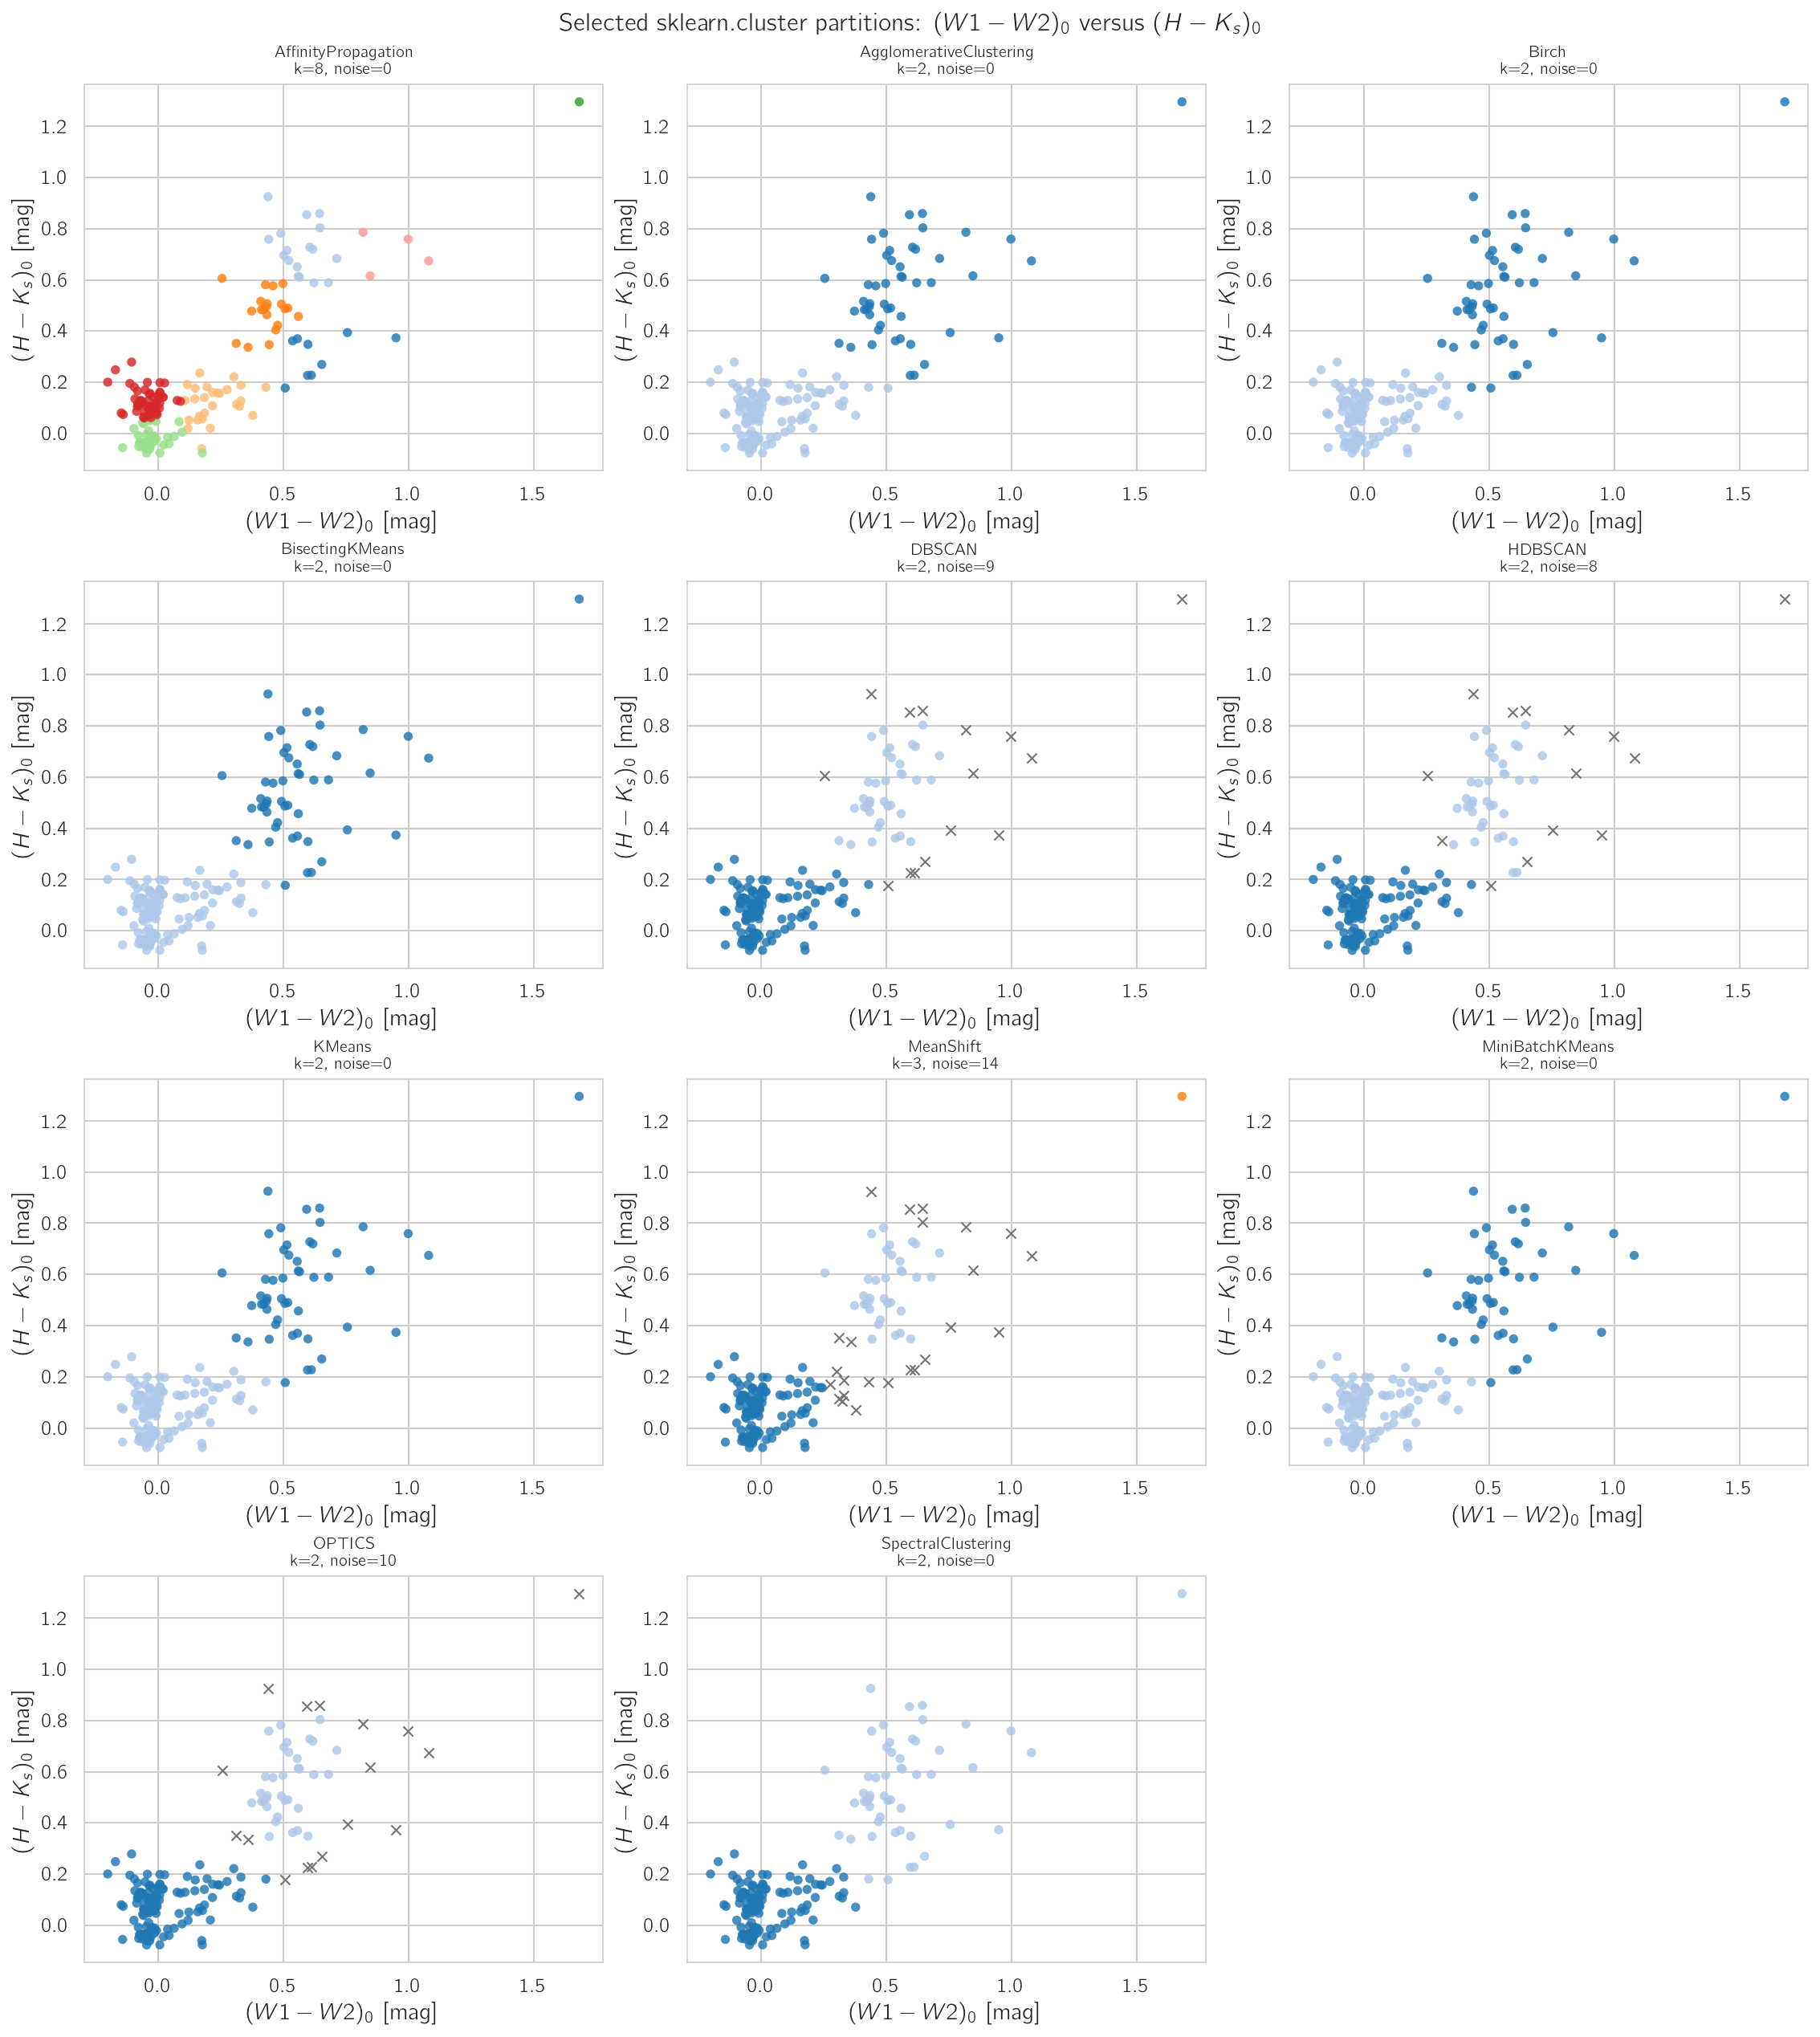

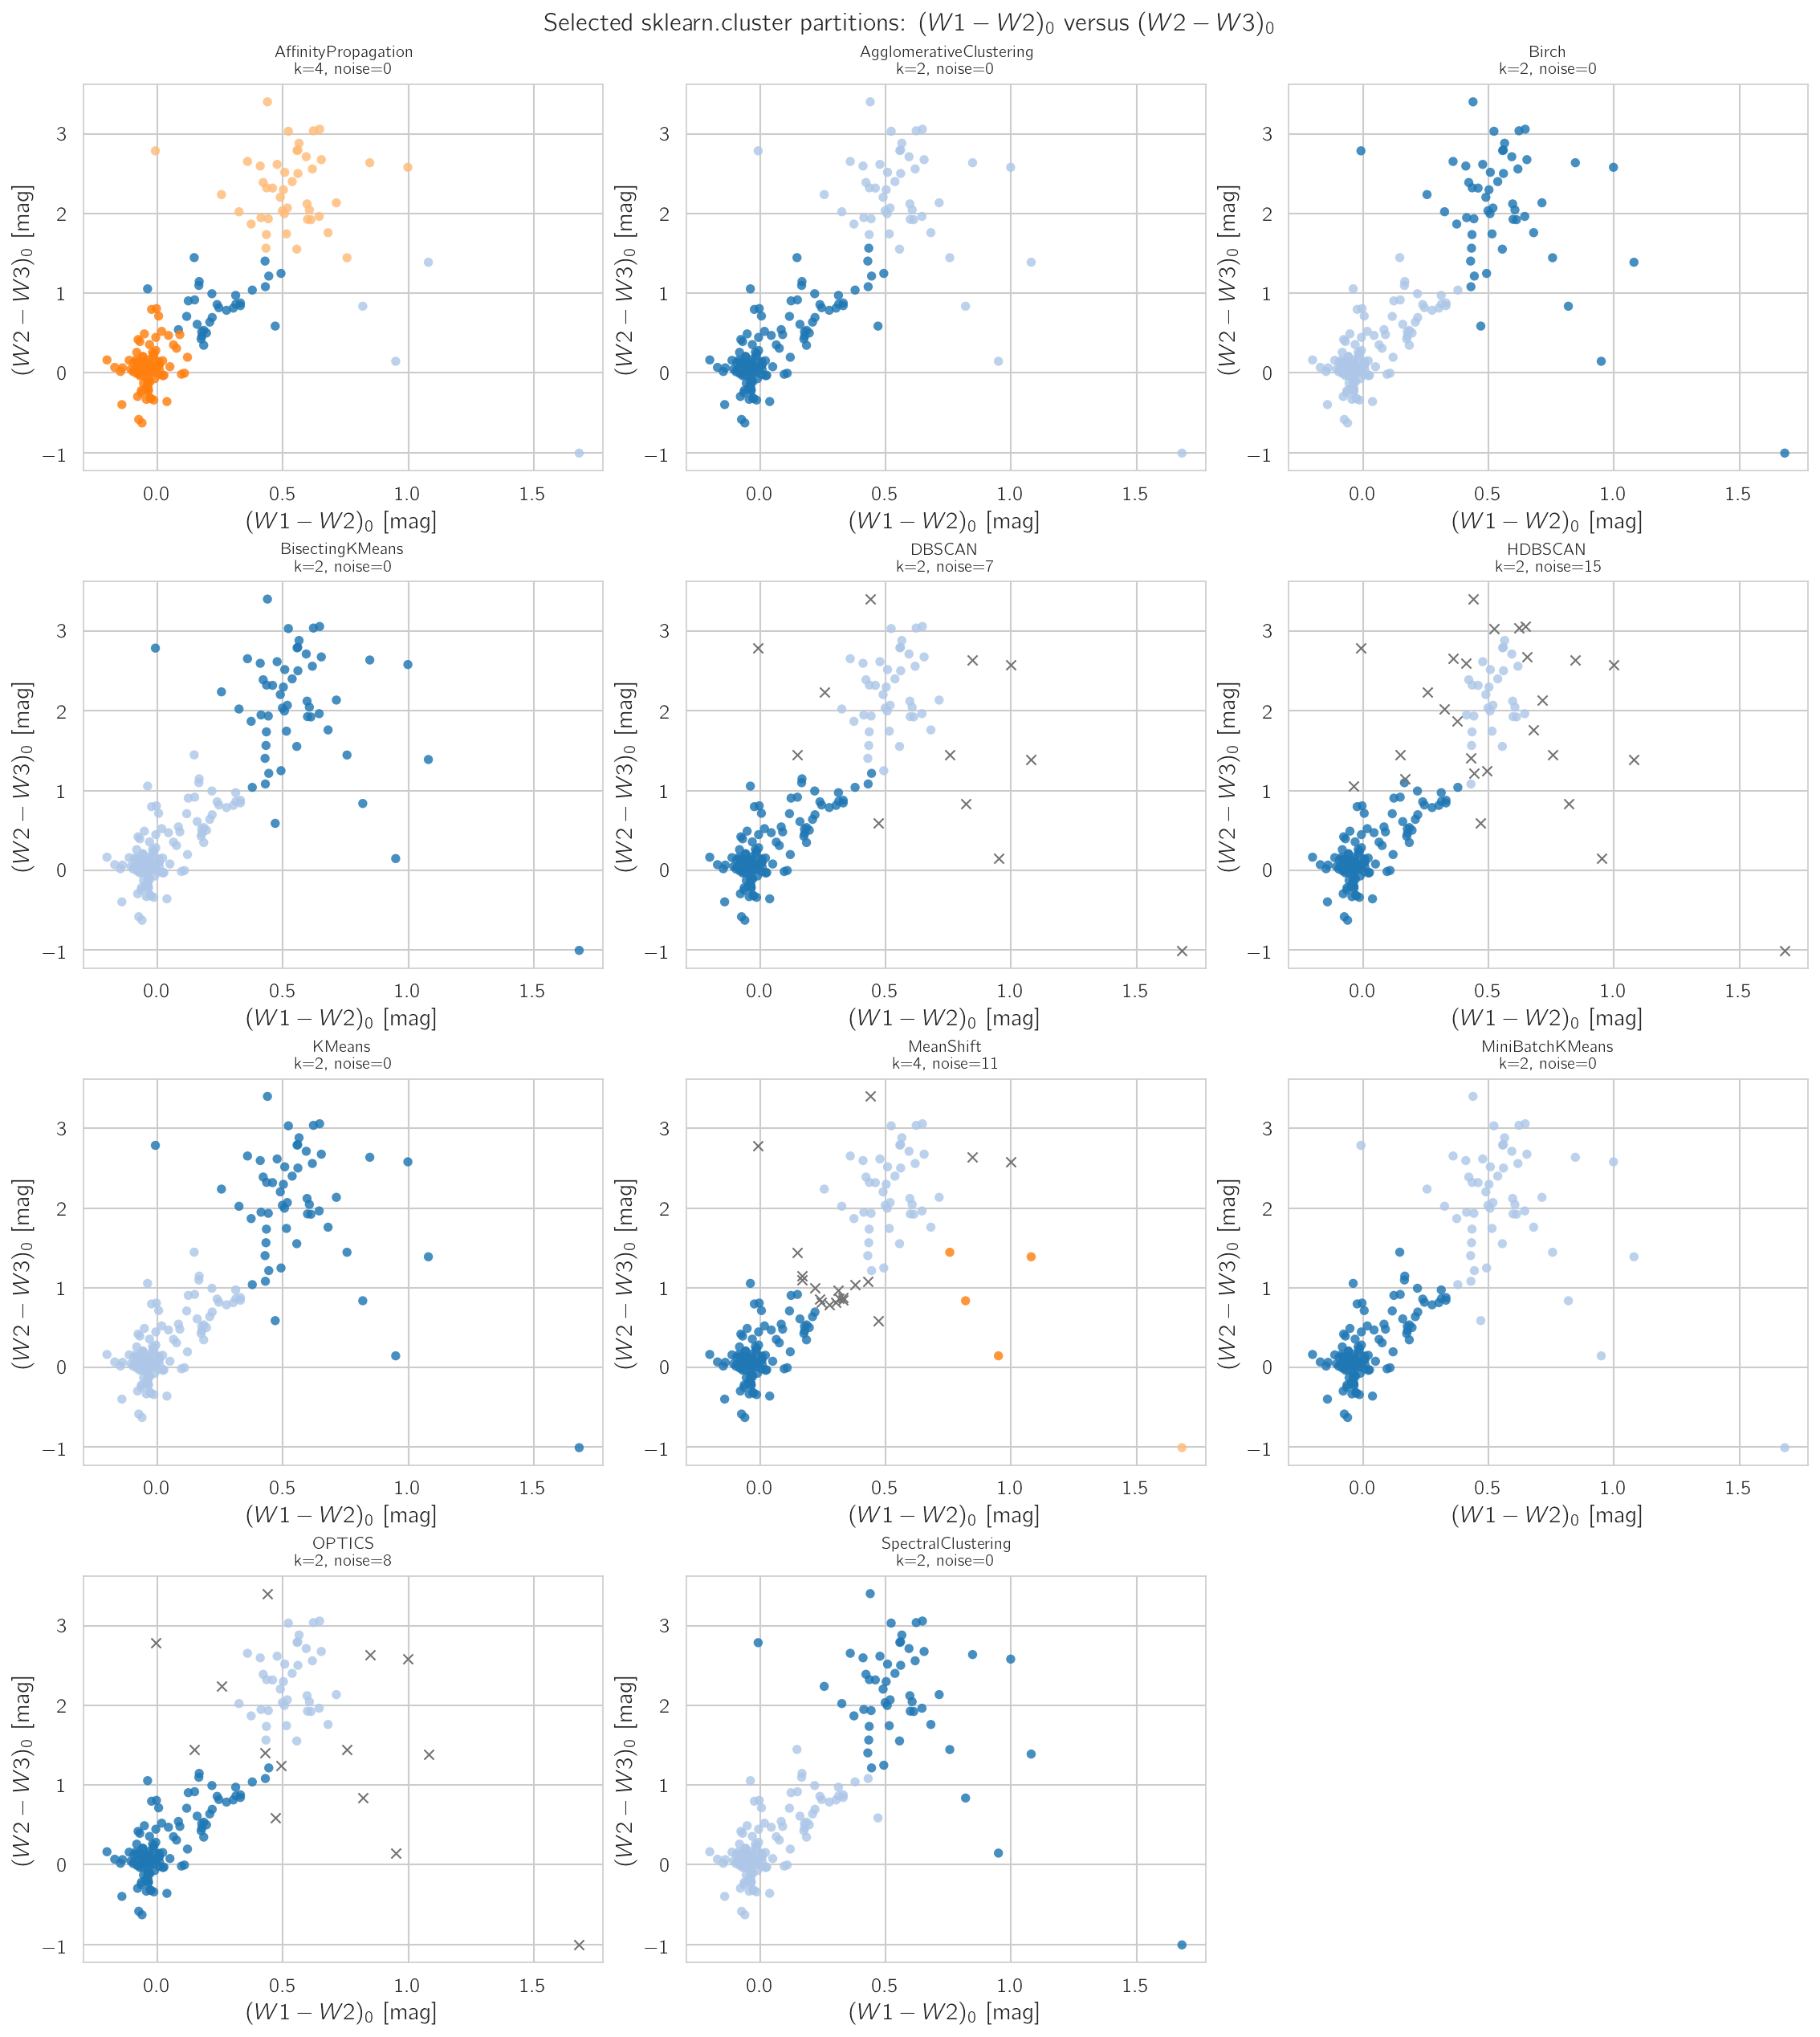

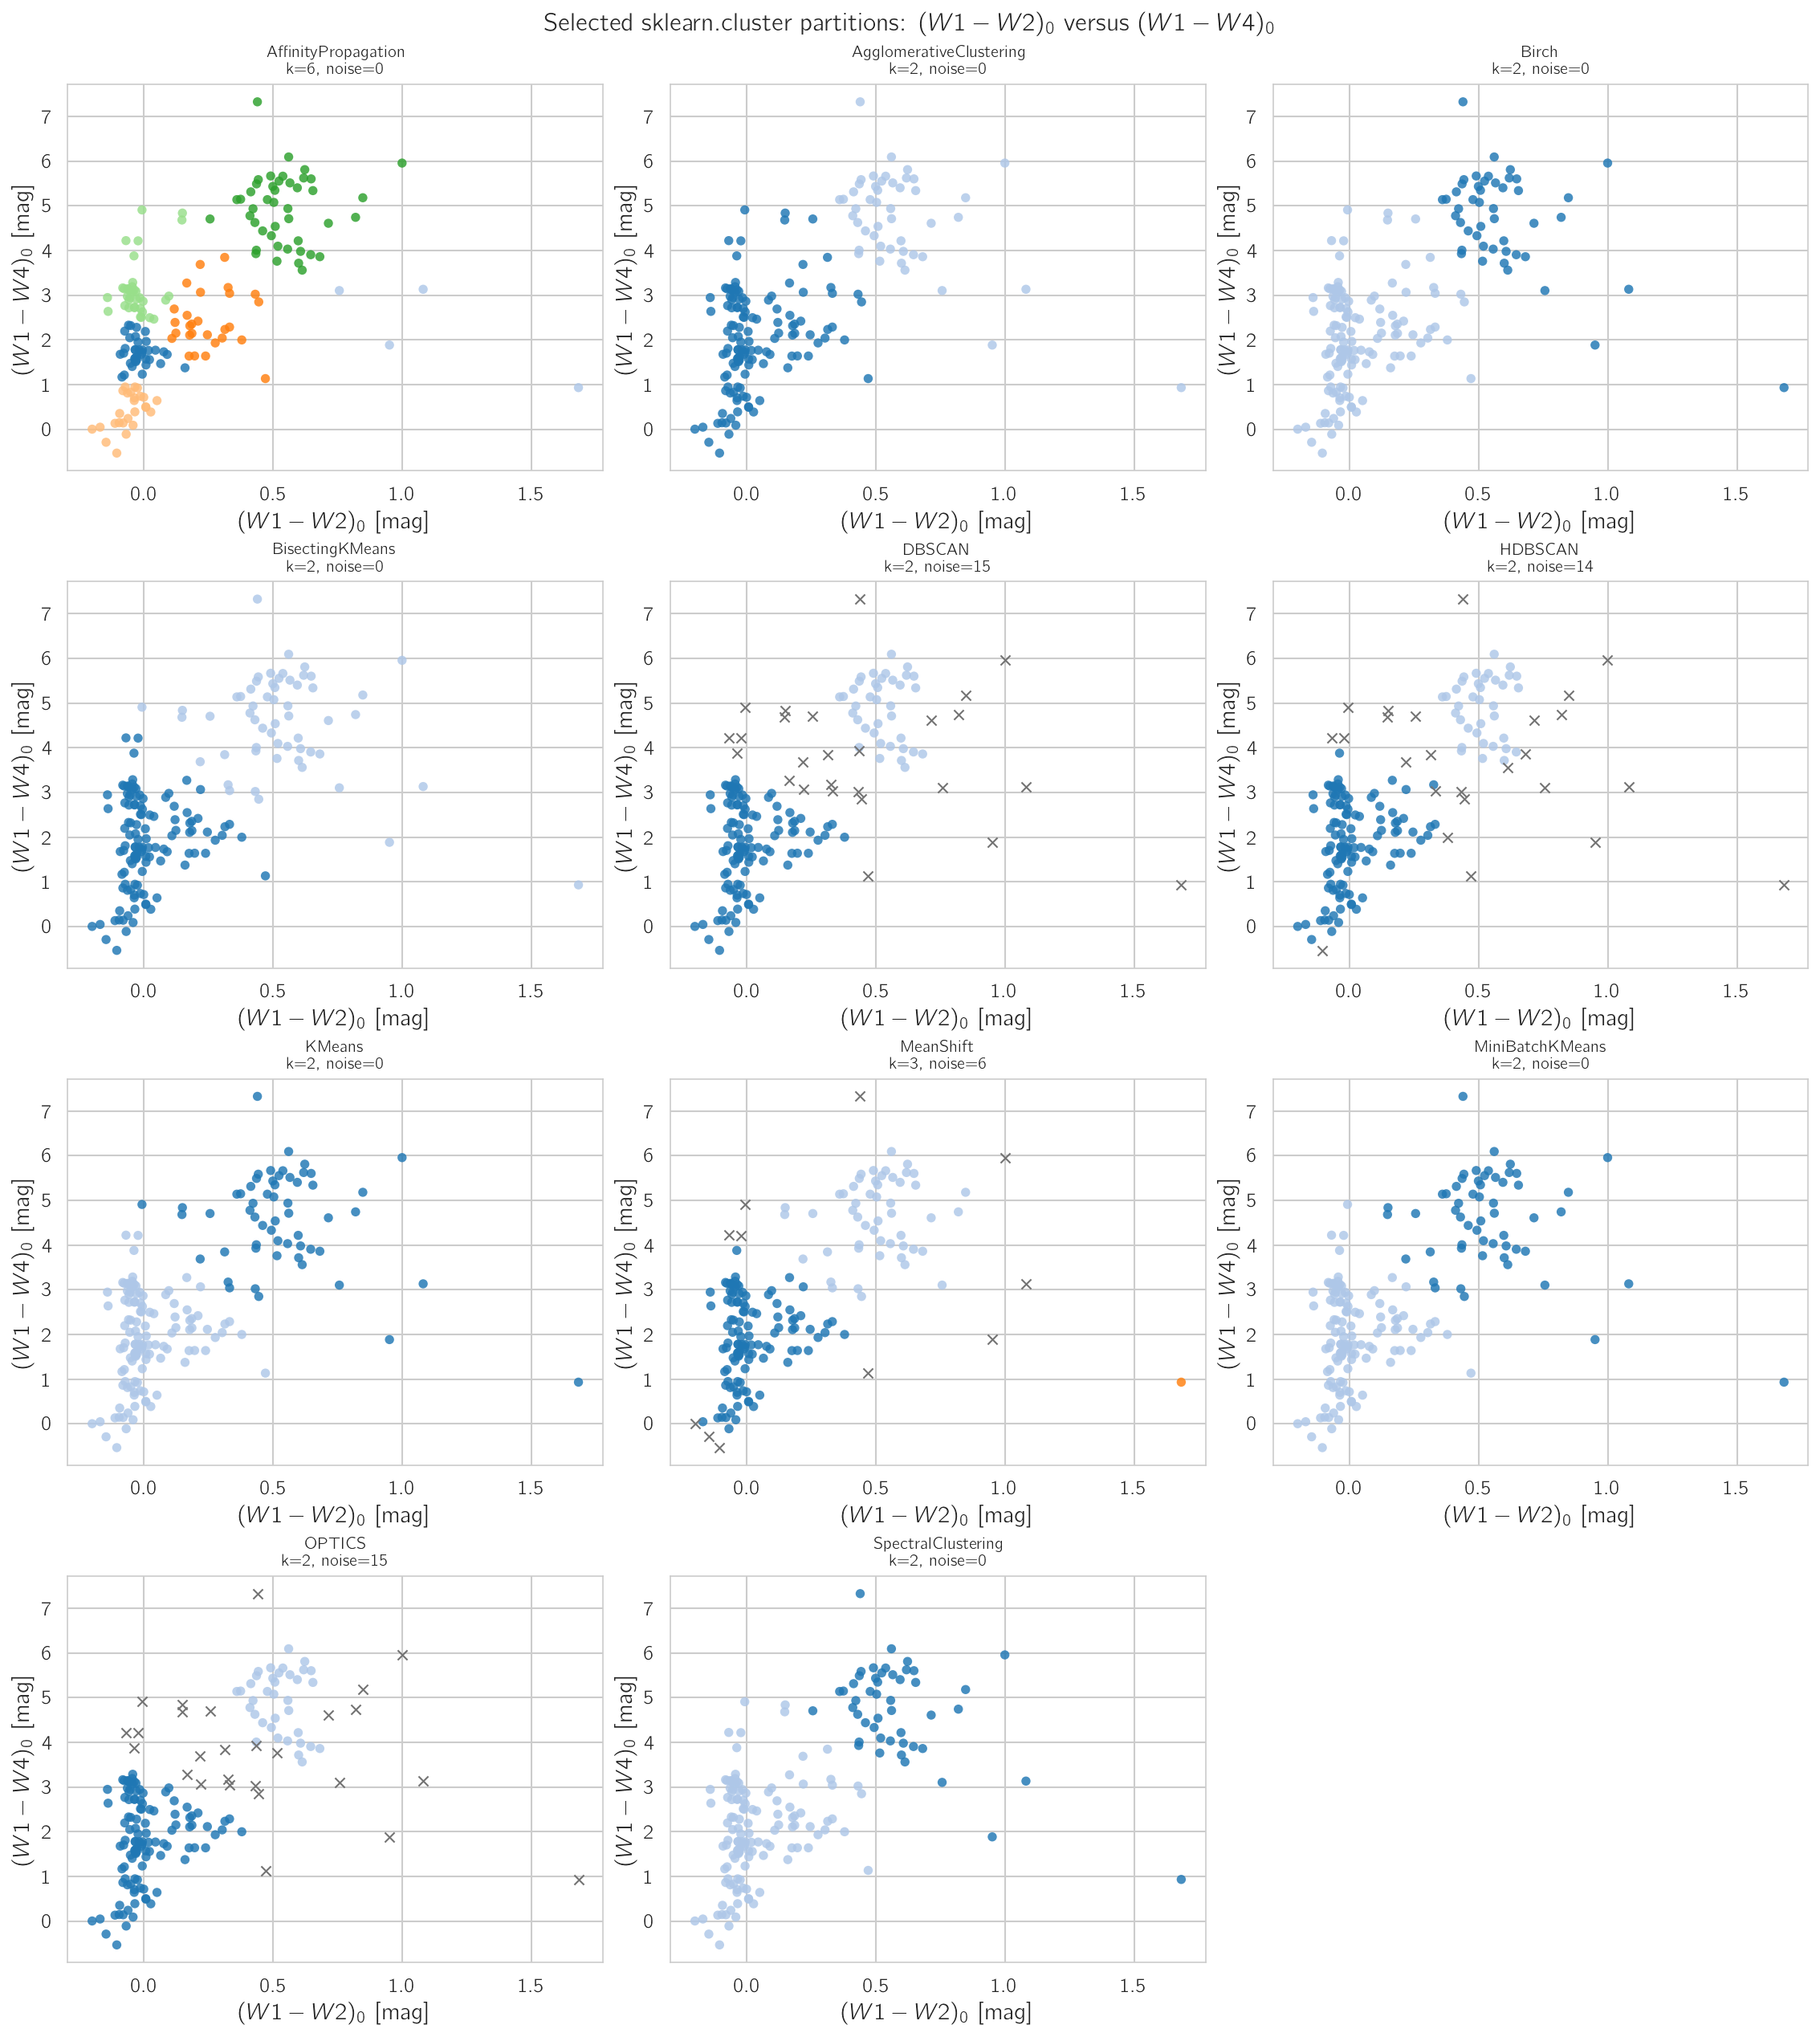

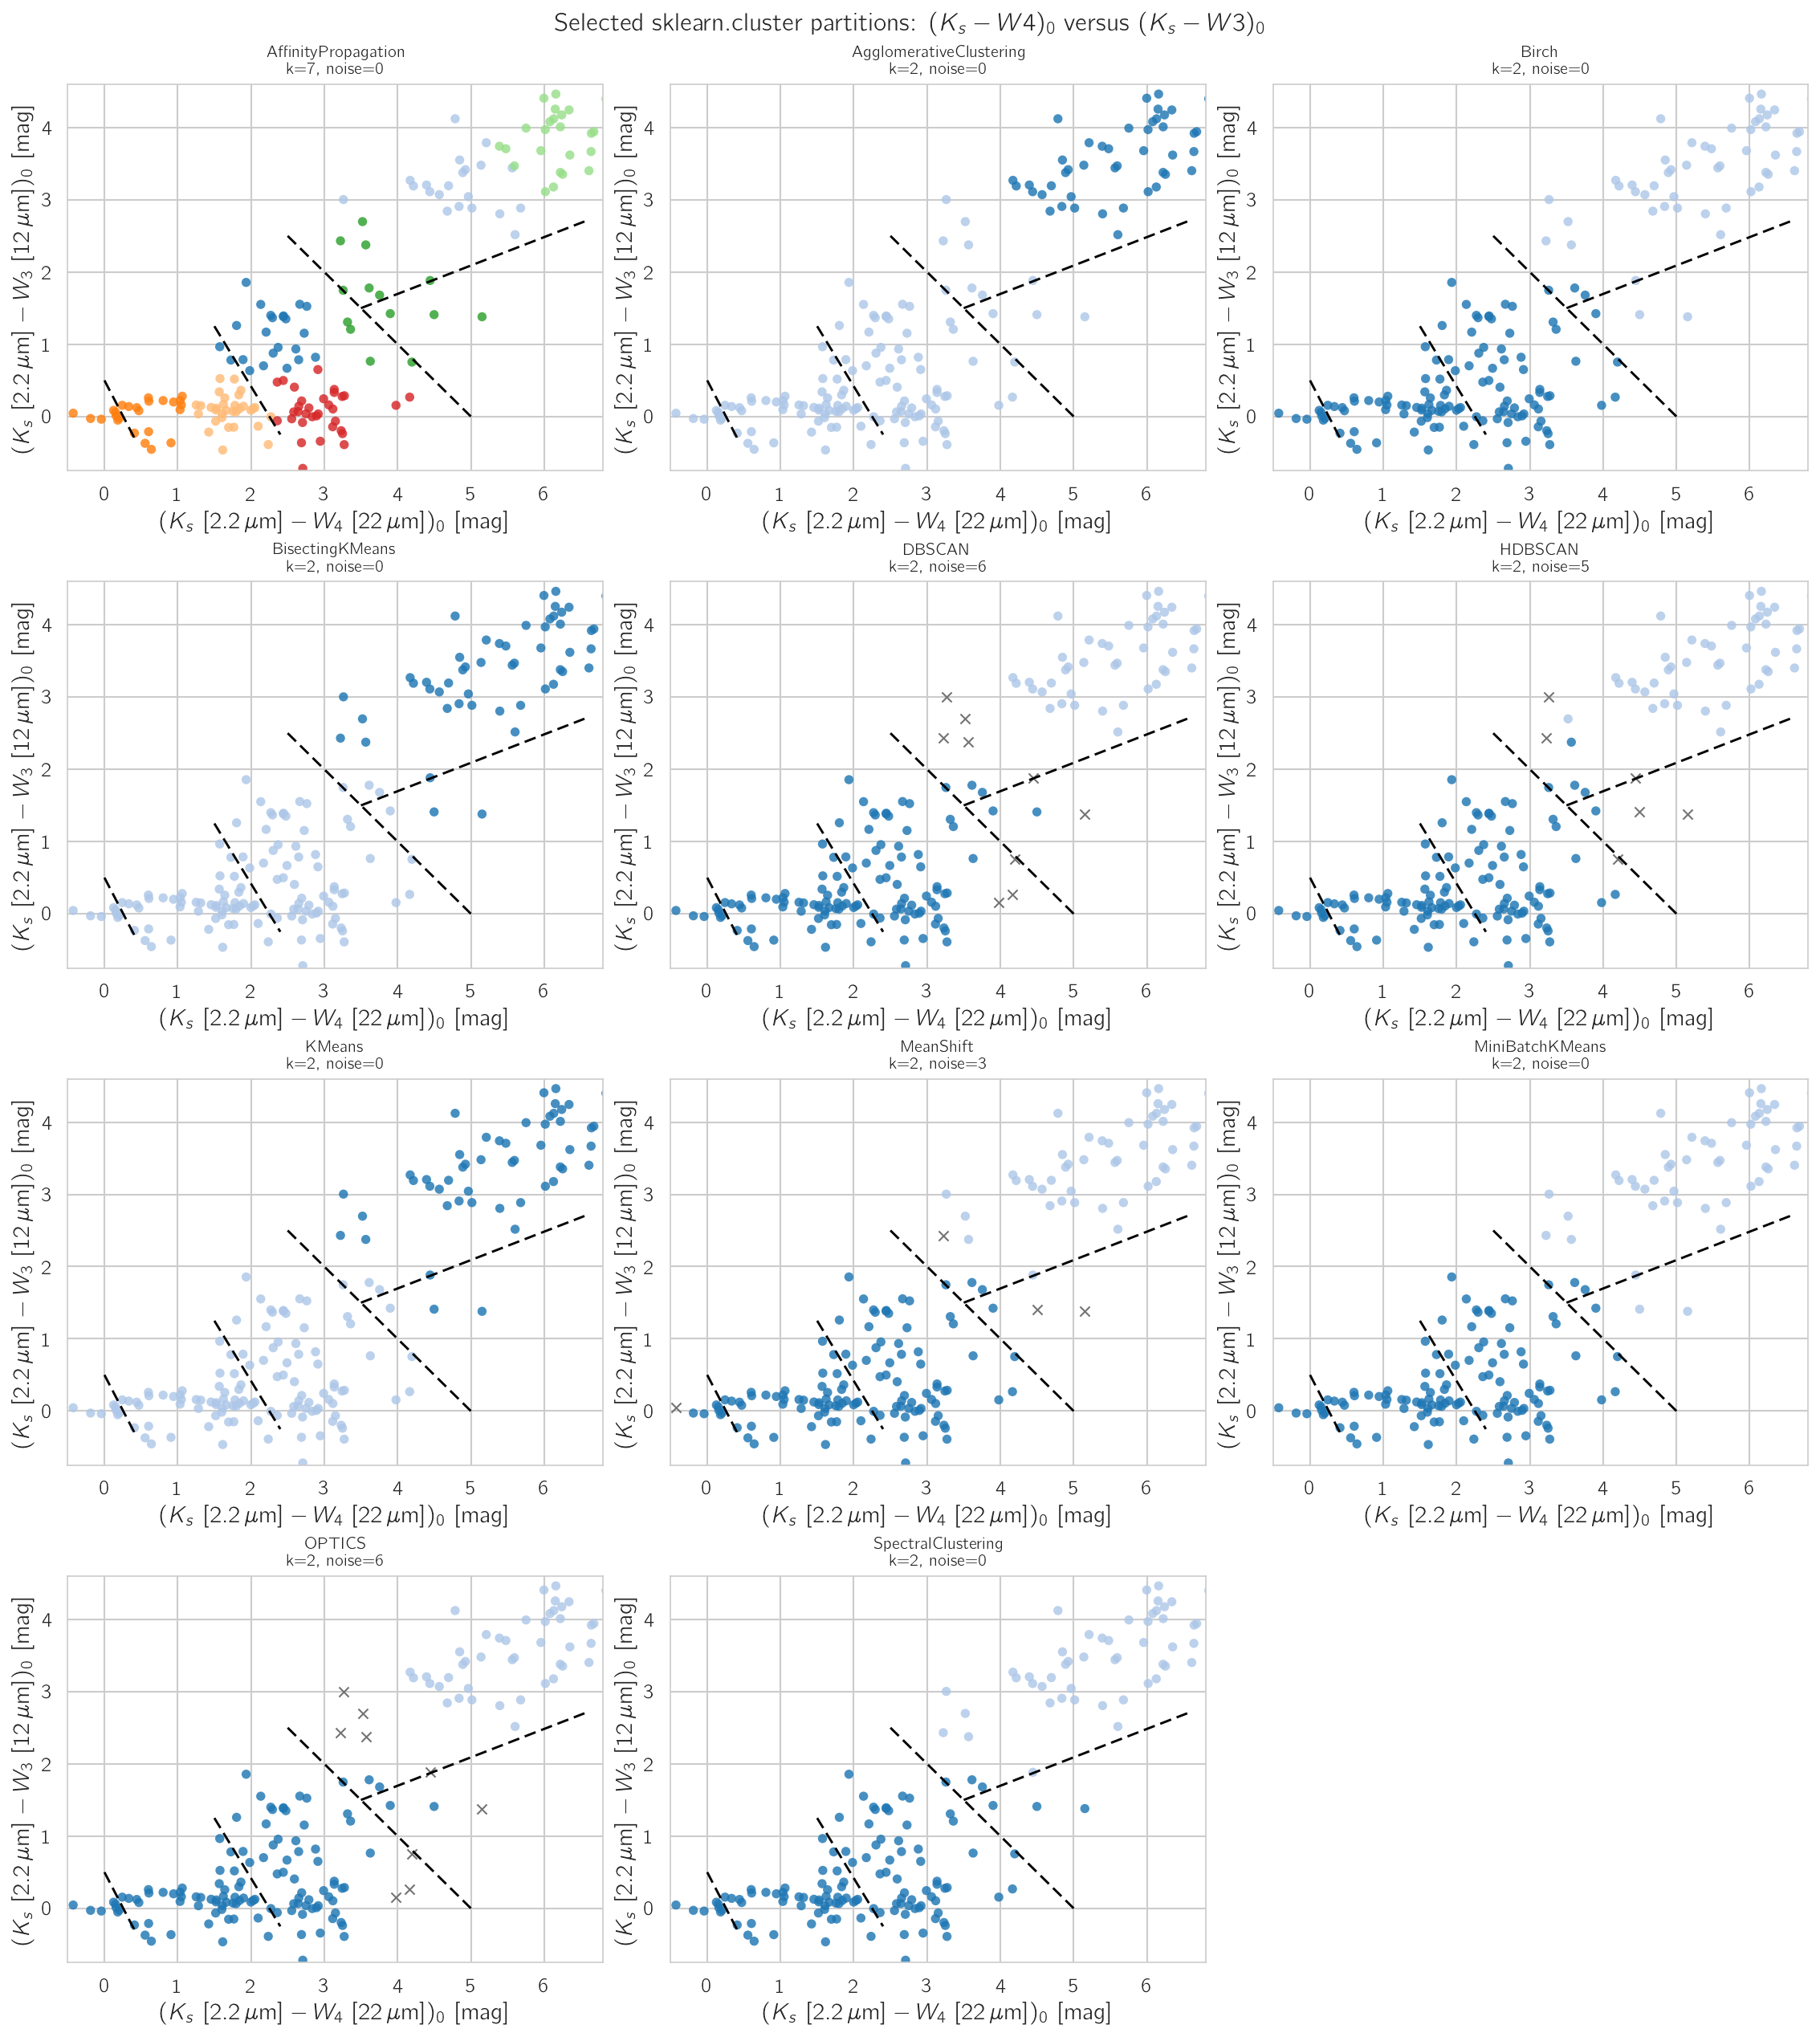

In [9]:
def plot_partition(ax, frame, x, y, labels, *, title):
    labels = np.asarray(labels)
    clusters = sorted(set(labels) - {-1})
    cmap = plt.get_cmap("tab20")
    for i, cluster_id in enumerate(clusters):
        mask = labels == cluster_id
        ax.scatter(
            frame.loc[mask, x],
            frame.loc[mask, y],
            s=30,
            alpha=0.82,
            color=cmap(i % 20),
            edgecolor="none",
        )
    noise = labels == -1
    if noise.any():
        ax.scatter(
            frame.loc[noise, x],
            frame.loc[noise, y],
            s=34,
            marker="x",
            linewidth=1.0,
            color="0.45",
        )
    ax.set_title(title, fontsize=10)


cluster_figures = {}
for space_name, cfg in SPACE_CONFIG.items():
    selected = best.loc[best["space"].eq(space_name)].sort_values("method").reset_index(drop=True)
    ncols = 3
    nrows = math.ceil(len(selected) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.2 * nrows), squeeze=False, constrained_layout=True)
    frame = space_data[space_name]["frame"]
    x, y = cfg["features"]
    for ax, row in zip(axes.flat, selected.itertuples(index=False)):
        labels = label_registry.get((space_name, row.spec_id))
        if labels is None:
            ax.text(0.5, 0.5, "fit failed", ha="center", va="center", transform=ax.transAxes)
        else:
            plot_partition(
                ax,
                frame,
                x,
                y,
                labels,
                title=(
                    f"{row.method}\n"
                    f"k={row.n_clusters}, noise={row.noise_fraction:.0%}, "
                    f"sil={row.silhouette:.2f}, stability={row.stability_ari_mean:.2f}"
                ),
            )
        if cfg.get("empirical_disk_boundaries", False):
            draw_empirical_disk_boundaries(ax, include_region_labels=False)
        ax.set_xlabel(cfg["xlabel"])
        ax.set_ylabel(cfg["ylabel"])
    for ax in axes.flat[len(selected):]:
        ax.set_visible(False)
    fig.suptitle(f"Selected sklearn.cluster partitions: {cfg['title']}", fontsize=15)
    cluster_figures[space_name] = fig
    plt.show()

## Alignment with the empirical disk-stage regions

This comparison is descriptive: the clustering algorithms see only the two standardized color coordinates, while the empirical labels come from the overlaid boundary geometry. Adjusted Rand index (ARI) and normalized mutual information (NMI) quantify overall agreement without requiring cluster numbers to match. The purity column reports the fraction of candidates captured by the dominant empirical region within each algorithmic cluster; it can be high for over-fragmented solutions, so read it alongside the cluster count, noise fraction, ARI, and NMI. Noise is retained as cluster `-1`.

In [10]:
DISK_SPACE_NAME = "disk_ks_w4_ks_w3"
disk_frame = space_data[DISK_SPACE_NAME]["frame"]
disk_selected = best.loc[best["space"].eq(DISK_SPACE_NAME)].sort_values("method")

alignment_rows = []
cluster_region_rows = []
for row in disk_selected.itertuples(index=False):
    labels = label_registry.get((DISK_SPACE_NAME, row.spec_id))
    if labels is None:
        continue
    regions = disk_frame["disk_region"].astype(str).to_numpy()
    region_codes = pd.Categorical(regions, categories=DISK_REGION_ORDER).codes
    counts = pd.crosstab(
        pd.Series(labels, name="cluster"),
        pd.Categorical(regions, categories=DISK_REGION_ORDER),
        dropna=False,
    ).reindex(columns=DISK_REGION_ORDER, fill_value=0)
    purity = float(counts.max(axis=1).sum() / counts.to_numpy().sum())
    alignment_rows.append(
        {
            "method": row.method,
            "n_clusters": row.n_clusters,
            "n_noise": row.n_noise,
            "noise_fraction": row.noise_fraction,
            "empirical_region_ari": adjusted_rand_score(region_codes, labels),
            "empirical_region_nmi": normalized_mutual_info_score(region_codes, labels),
            "cluster_region_purity": purity,
            "params_json": row.params_json,
        }
    )
    for cluster_id, count_row in counts.iterrows():
        payload = {
            "method": row.method,
            "cluster": int(cluster_id),
            "n": int(count_row.sum()),
        }
        payload.update({region: int(count_row[region]) for region in DISK_REGION_ORDER})
        cluster_region_rows.append(payload)

empirical_region_alignment = pd.DataFrame(alignment_rows).sort_values(
    ["empirical_region_nmi", "empirical_region_ari"], ascending=False
)
disk_cluster_region_counts = pd.DataFrame(cluster_region_rows).sort_values(["method", "cluster"])

display(
    empirical_region_alignment.style.format(
        {
            "noise_fraction": "{:.1%}",
            "empirical_region_ari": "{:.3f}",
            "empirical_region_nmi": "{:.3f}",
            "cluster_region_purity": "{:.1%}",
        }
    )
)
display(disk_cluster_region_counts)

,method,n_clusters,n_noise,noise_fraction,empirical_region_ari,empirical_region_nmi,cluster_region_purity,params_json
0,AffinityPropagation,7,0,0.0%,0.486,0.661,89.7%,"{""damping"": 0.75, ""preference"": -4.13654}"
10,SpectralClustering,2,0,0.0%,0.422,0.568,63.4%,"{""affinity"": ""nearest_neighbors"", ""n_clusters"": 2}"
3,BisectingKMeans,2,0,0.0%,0.435,0.564,63.4%,"{""n_clusters"": 2}"
6,KMeans,2,0,0.0%,0.435,0.564,63.4%,"{""n_clusters"": 2}"
2,Birch,2,0,0.0%,0.435,0.564,63.4%,"{""n_clusters"": 8, ""threshold"": 0.75}"
8,MiniBatchKMeans,2,0,0.0%,0.435,0.564,63.4%,"{""n_clusters"": 2}"
7,MeanShift,2,6,3.4%,0.431,0.562,63.4%,"{""bandwidth"": 1.275778, ""cluster_all"": false}"
5,HDBSCAN,2,8,4.6%,0.386,0.520,62.3%,"{""min_cluster_size"": 8, ""min_samples"": null}"
4,DBSCAN,2,11,6.3%,0.372,0.502,61.7%,"{""eps"": 0.352803, ""min_samples"": 5}"
9,OPTICS,2,11,6.3%,0.372,0.502,61.7%,"{""cluster_method"": ""dbscan"", ""eps"": 0.352803, ""min_samples"": 5}"


,method,cluster,n,Diskless,Debris,Evolved,Full,Transition
0,AffinityPropagation,0,23,0,2,21,0,0
1,AffinityPropagation,1,21,0,0,0,21,0
2,AffinityPropagation,2,25,8,17,0,0,0
3,AffinityPropagation,3,32,0,31,1,0,0
4,AffinityPropagation,4,14,0,0,4,7,3
5,AffinityPropagation,5,27,0,0,0,27,0
6,AffinityPropagation,6,33,0,0,33,0,0
7,AgglomerativeClustering,0,47,0,0,0,47,0
8,AgglomerativeClustering,1,128,8,50,59,8,3
9,Birch,0,121,8,50,59,3,1


## Pairwise agreement between methods

ARI near 1 means two methods produced nearly the same partition after ignoring label-number permutations; ARI near 0 indicates agreement comparable to unrelated partitions. Noise is retained as a label in this comparison, so consult the noise fractions alongside each matrix.

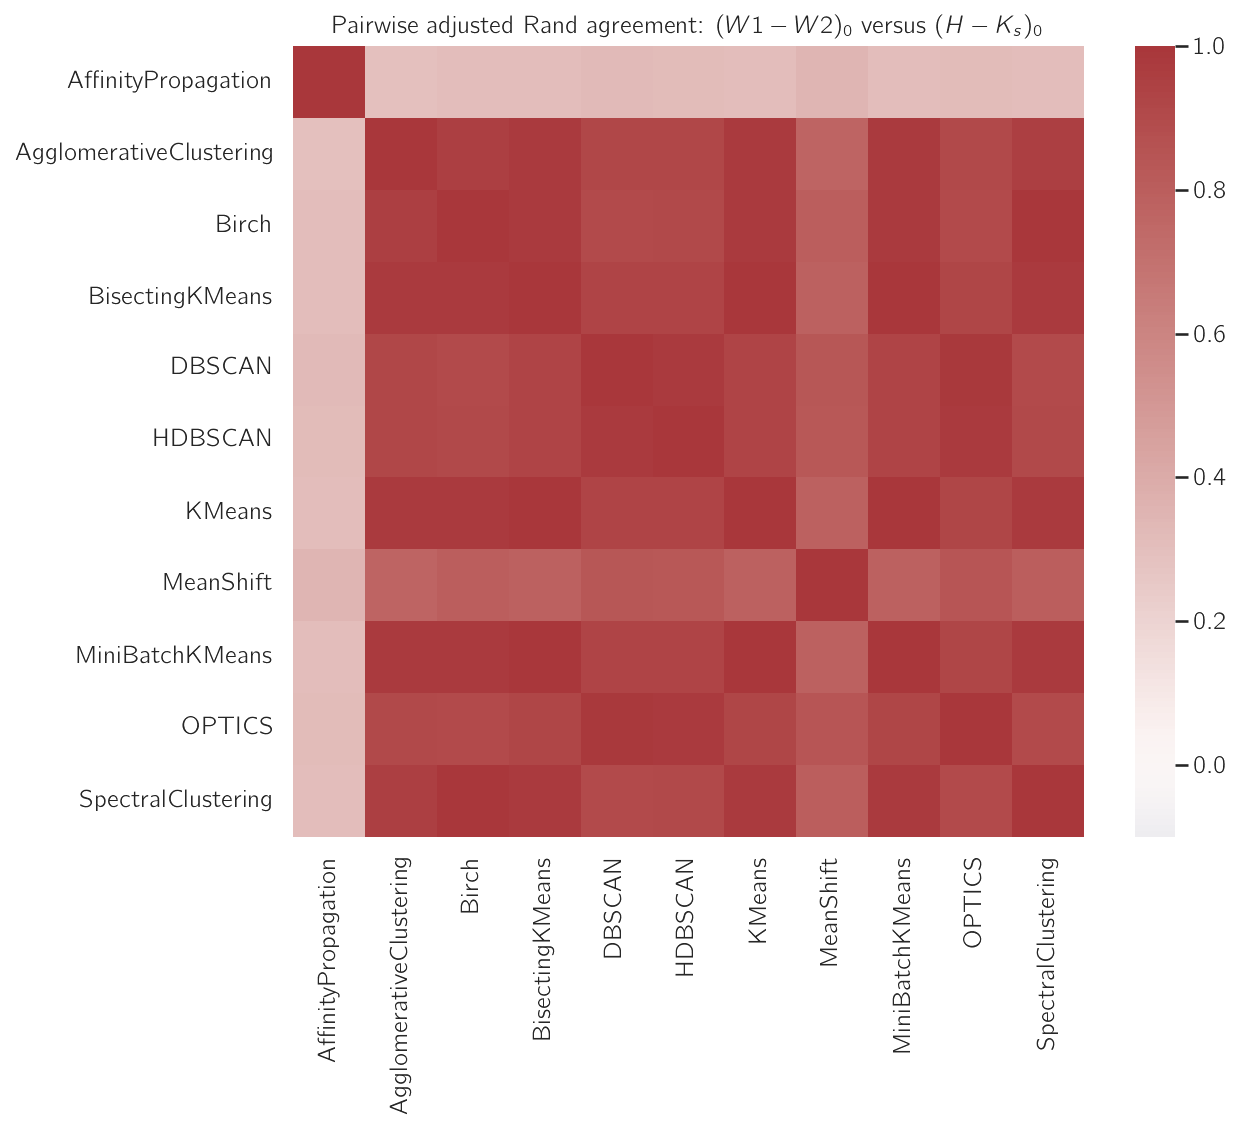

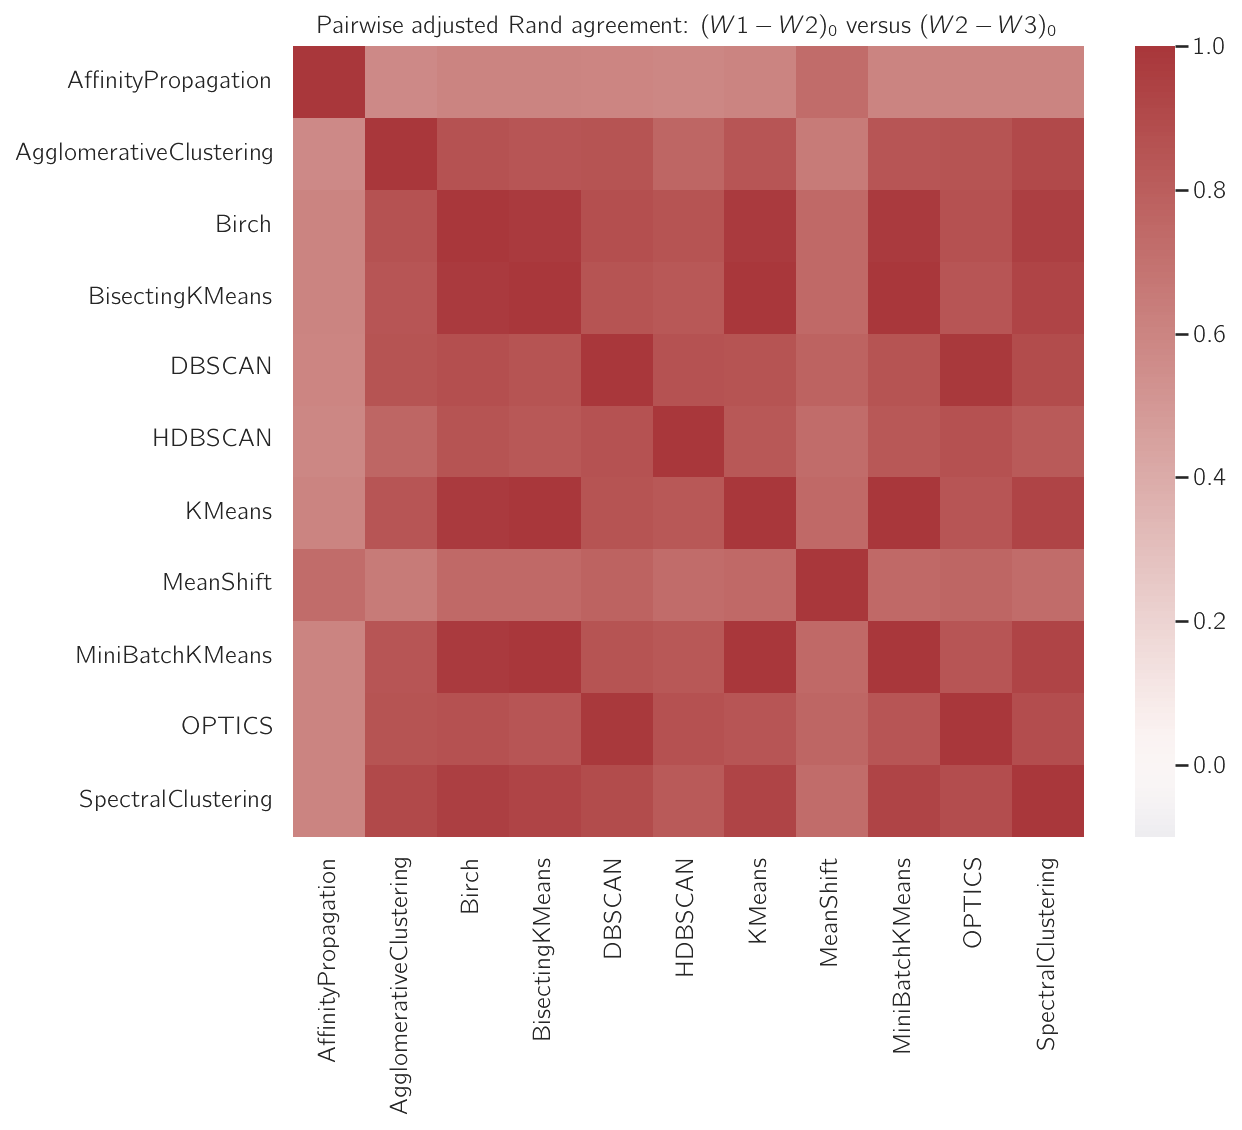

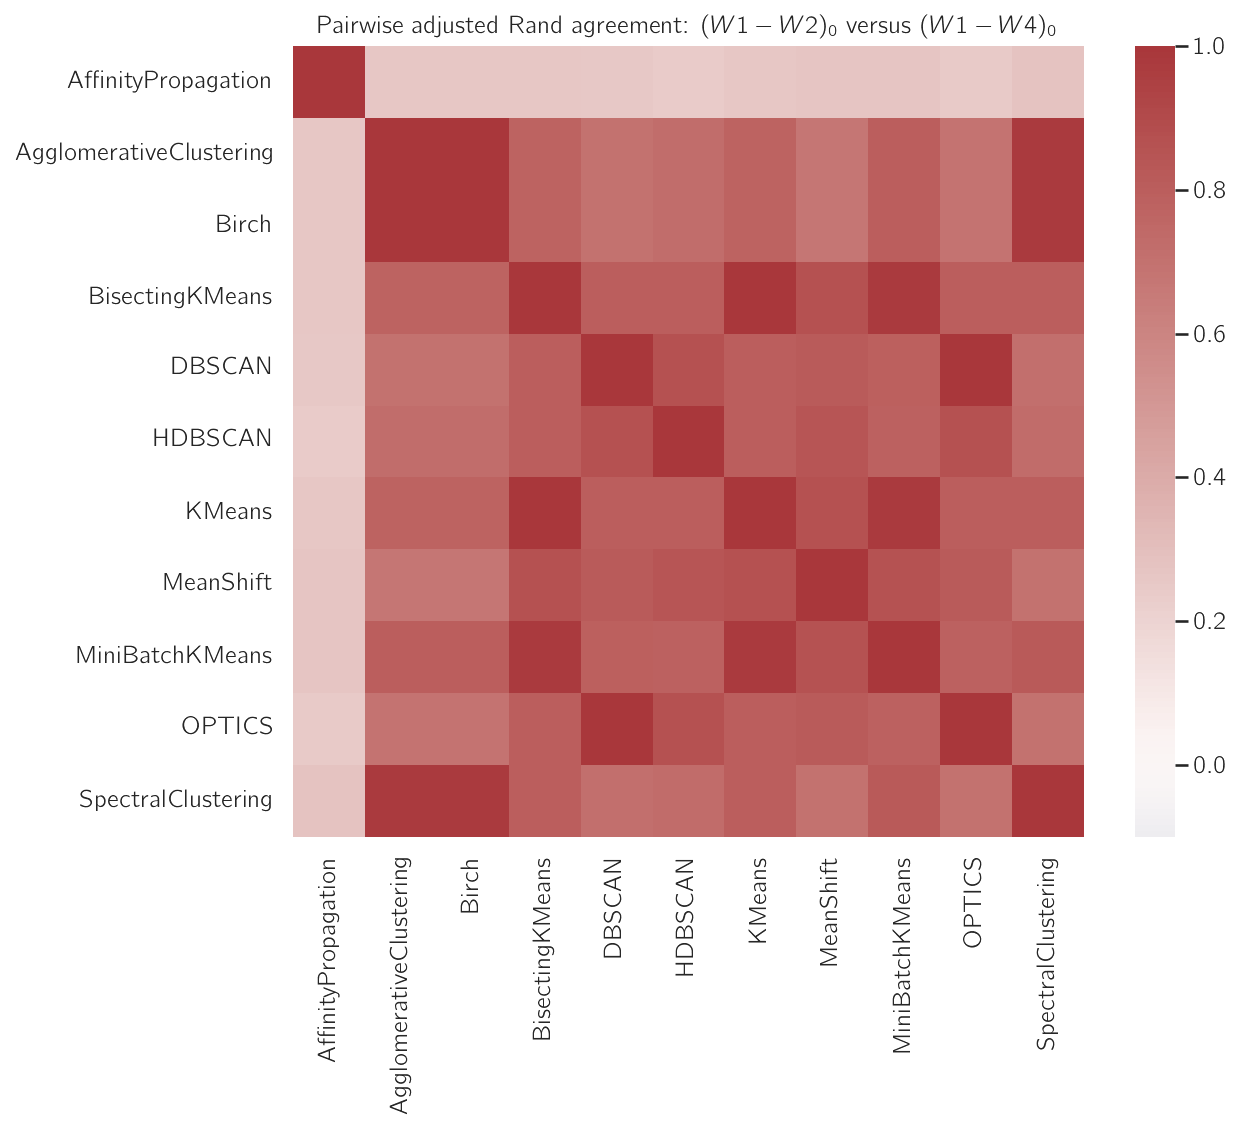

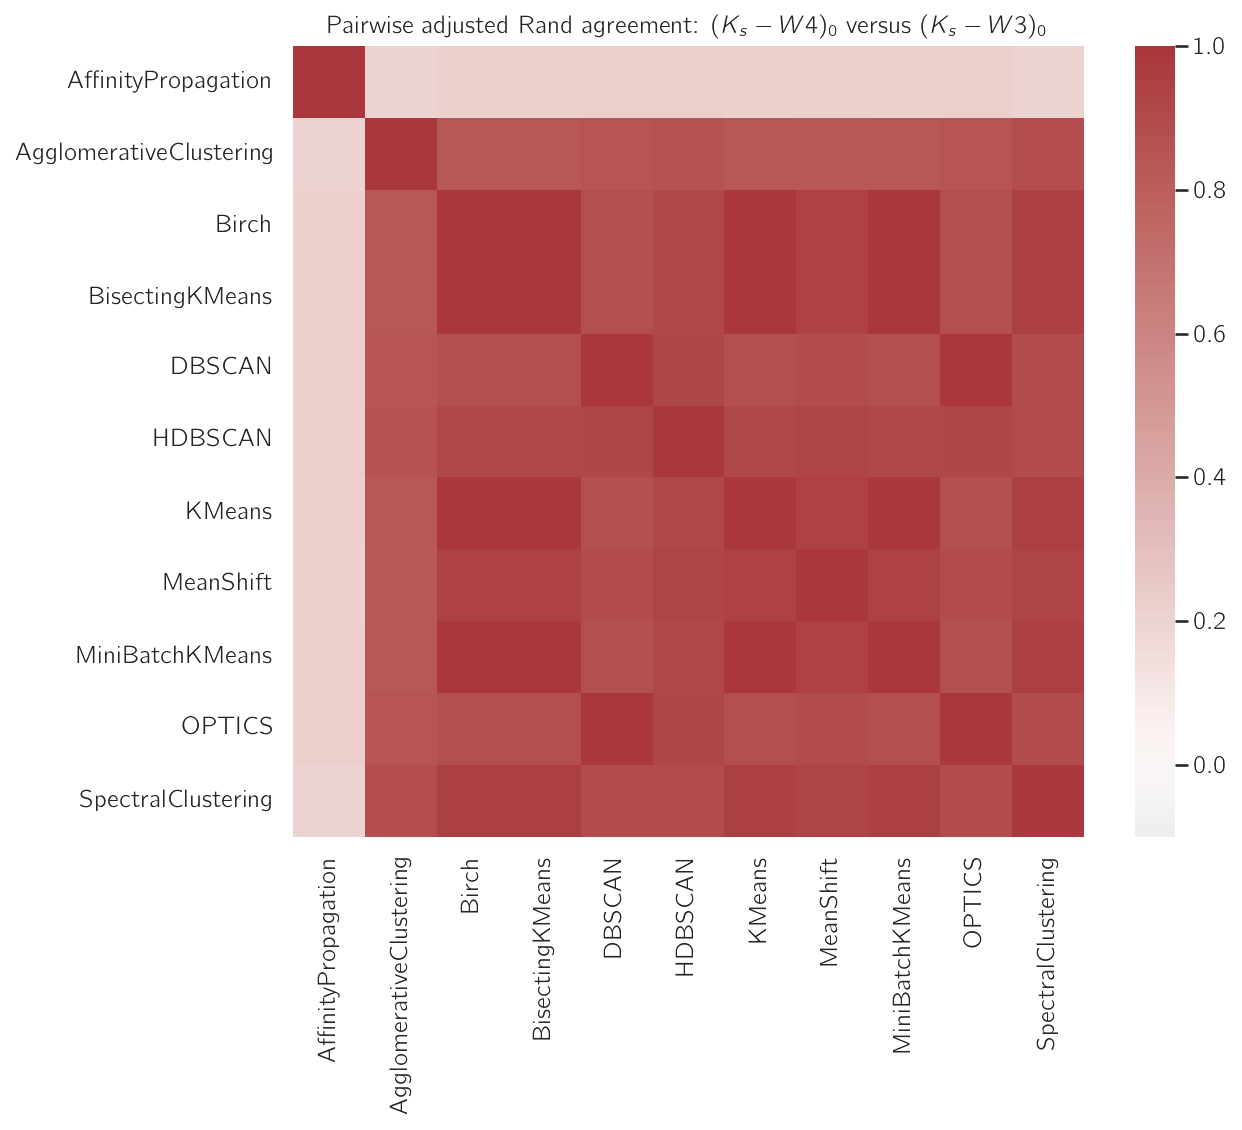

In [11]:
agreement_tables = {}
agreement_figures = {}
for space_name, cfg in SPACE_CONFIG.items():
    selected = best.loc[best["space"].eq(space_name)].sort_values("method")
    label_map = {
        row.method: label_registry[(space_name, row.spec_id)]
        for row in selected.itertuples(index=False)
        if (space_name, row.spec_id) in label_registry
    }
    methods = list(label_map)
    agreement = pd.DataFrame(index=methods, columns=methods, dtype=float)
    for method_a in methods:
        for method_b in methods:
            agreement.loc[method_a, method_b] = adjusted_rand_score(label_map[method_a], label_map[method_b])
    agreement_tables[space_name] = agreement

    fig, ax = plt.subplots(figsize=(9, 7.5))
    sns.heatmap(agreement, vmin=-0.1, vmax=1.0, center=0.0, cmap="vlag", square=True, ax=ax)
    ax.set_title(f"Pairwise adjusted Rand agreement: {cfg['title']}")
    fig.tight_layout()
    agreement_figures[space_name] = fig
    plt.show()

## Candidate-level memberships and output files

The wide membership tables make disagreements inspectable candidate by candidate. Each plane has its own candidate set and its own independent labels.

In [12]:
membership_tables = {}
for space_name, cfg in SPACE_CONFIG.items():
    membership = space_data[space_name]["frame"].copy()
    selected = best.loc[best["space"].eq(space_name)].sort_values("method")
    for row in selected.itertuples(index=False):
        labels = label_registry.get((space_name, row.spec_id))
        if labels is not None:
            membership[f"cluster__{row.method}"] = labels
    membership_tables[space_name] = membership
    display(Markdown(f"### {cfg['title']}"))
    display(membership.head(20))

if WRITE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    benchmark.to_csv(OUTPUT_DIR / "all_configurations.csv", index=False)
    best.to_csv(OUTPUT_DIR / "best_configuration_by_method.csv", index=False)
    coverage.to_csv(OUTPUT_DIR / "plane_coverage.csv", index=False)
    disk_boundary_table.to_csv(OUTPUT_DIR / "disk_empirical_boundaries_used.csv", index=False)
    empirical_region_alignment.to_csv(OUTPUT_DIR / "disk_empirical_region_alignment_by_method.csv", index=False)
    disk_cluster_region_counts.to_csv(OUTPUT_DIR / "disk_cluster_empirical_region_counts.csv", index=False)
    (OUTPUT_DIR / "extinction_correction_metadata.json").write_text(
        json.dumps(extinction_metadata, indent=2, sort_keys=True) + "\n", encoding="utf-8"
    )
    for space_name in SPACE_CONFIG:
        membership_tables[space_name].to_csv(OUTPUT_DIR / f"{space_name}_memberships.csv", index=False)
        agreement_tables[space_name].to_csv(OUTPUT_DIR / f"{space_name}_pairwise_ari.csv")
        cluster_figures[space_name].savefig(OUTPUT_DIR / f"{space_name}_cluster_comparison.pdf", bbox_inches="tight")
        agreement_figures[space_name].savefig(OUTPUT_DIR / f"{space_name}_pairwise_ari.pdf", bbox_inches="tight")
    print(f"Wrote benchmark tables and figures to {OUTPUT_DIR}")
else:
    print("WRITE_OUTPUTS=False: no files written.")

### $(W1-W2)_0$ versus $(H-K_s)_0$

,candidate_id,w1_w2_0,H_K_0,cluster__AffinityPropagation,cluster__AgglomerativeClustering,cluster__Birch,cluster__BisectingKMeans,cluster__DBSCAN,cluster__HDBSCAN,cluster__KMeans,cluster__MeanShift,cluster__MiniBatchKMeans,cluster__OPTICS,cluster__SpectralClustering
0,stv_103079502524,-0.080948,0.113232,6,1,1,1,0,0,1,0,1,0,0
1,stv_103080542701,0.174283,-0.059228,3,1,1,1,0,0,1,0,1,0,0
2,stv_111669273145,-0.034543,-0.052444,5,1,1,1,0,0,1,0,1,0,0
3,stv_111669291649,0.195708,0.182186,3,1,1,1,0,0,1,0,1,0,0
4,stv_111669305159,-0.045644,-0.076398,5,1,1,1,0,0,1,0,1,0,0
5,stv_111669455609,0.037961,-0.014675,5,1,1,1,0,0,1,0,1,0,0
6,stv_111669512802,-0.008000,0.047000,5,1,1,1,0,0,1,0,1,0,0
7,stv_111669557747,0.312932,0.113692,3,1,1,1,0,0,1,-1,1,0,0
8,stv_111670309173,-0.058186,0.064667,6,1,1,1,0,0,1,0,1,0,0
9,stv_111670444883,0.008381,0.158210,6,1,1,1,0,0,1,0,1,0,0


### $(W1-W2)_0$ versus $(W2-W3)_0$

,candidate_id,w1_w2_0,w2_w3_0,cluster__AffinityPropagation,cluster__AgglomerativeClustering,cluster__Birch,cluster__BisectingKMeans,cluster__DBSCAN,cluster__HDBSCAN,cluster__KMeans,cluster__MeanShift,cluster__MiniBatchKMeans,cluster__OPTICS,cluster__SpectralClustering
0,stv_103079502524,-0.080948,-0.009542,2,0,1,1,0,0,1,0,0,0,1
1,stv_103080542701,0.174283,0.425878,0,0,1,1,0,0,1,0,0,0,1
2,stv_111669273145,-0.034543,-0.098823,2,0,1,1,0,0,1,0,0,0,1
3,stv_111669291649,0.195708,0.501377,0,0,1,1,0,0,1,0,0,0,1
4,stv_111669305159,-0.045644,0.019480,2,0,1,1,0,0,1,0,0,0,1
5,stv_111669455609,0.037961,-0.359345,2,0,1,1,0,0,1,0,0,0,1
6,stv_111669512802,-0.008000,2.788000,3,1,0,0,-1,-1,0,-1,1,-1,0
7,stv_111669557747,0.312932,0.864056,0,0,1,1,0,0,1,-1,0,0,1
8,stv_111670309173,-0.058186,0.071593,2,0,1,1,0,0,1,0,0,0,1
9,stv_111670444883,0.008381,0.036918,2,0,1,1,0,0,1,0,0,0,1


### $(W1-W2)_0$ versus $(W1-W4)_0$

,candidate_id,w1_w2_0,w1_w4_0,cluster__AffinityPropagation,cluster__AgglomerativeClustering,cluster__Birch,cluster__BisectingKMeans,cluster__DBSCAN,cluster__HDBSCAN,cluster__KMeans,cluster__MeanShift,cluster__MiniBatchKMeans,cluster__OPTICS,cluster__SpectralClustering
0,stv_103079502524,-0.080948,0.141511,3,0,1,0,0,0,1,0,1,0,1
1,stv_103080542701,0.174283,1.638161,2,0,1,0,0,0,1,0,1,0,1
2,stv_111669273145,-0.034543,1.780634,0,0,1,0,0,0,1,0,1,0,1
3,stv_111669291649,0.195708,1.641085,2,0,1,0,0,0,1,0,1,0,1
4,stv_111669305159,-0.045644,3.189837,5,0,1,0,0,0,1,0,1,0,1
5,stv_111669455609,0.037961,2.464616,5,0,1,0,0,0,1,0,1,0,1
6,stv_111669512802,-0.008000,4.908000,5,0,1,1,-1,-1,0,-1,1,-1,1
7,stv_111669557747,0.312932,2.233988,2,0,1,0,0,0,1,0,1,0,1
8,stv_111670309173,-0.058186,2.898407,5,0,1,0,0,0,1,0,1,0,1
9,stv_111670444883,0.008381,1.966299,0,0,1,0,0,0,1,0,1,0,1


### $(K_s-W4)_0$ versus $(K_s-W3)_0$

,candidate_id,ks_w4_0,ks_w3_0,disk_region,ks_w4_err,ks_w3_err,cluster__AffinityPropagation,cluster__AgglomerativeClustering,cluster__Birch,cluster__BisectingKMeans,cluster__DBSCAN,cluster__HDBSCAN,cluster__KMeans,cluster__MeanShift,cluster__MiniBatchKMeans,cluster__OPTICS,cluster__SpectralClustering
0,stv_103079502524,0.181413,-0.050587,Diskless,0.209538,0.026627,2,1,0,1,0,0,1,0,0,0,0
1,stv_103080542701,2.206263,1.168263,Evolved,0.425425,0.057245,0,1,0,1,0,0,1,0,0,0,0
2,stv_111669273145,1.765655,-0.148345,Debris,0.018000,0.091782,3,1,0,1,0,0,1,0,0,0,0
3,stv_111669291649,1.725664,0.781663,Debris,0.274729,0.044721,0,1,0,1,0,0,1,0,0,0,0
4,stv_111669305159,3.151847,-0.064153,Evolved,0.023000,0.023000,6,1,0,1,0,0,1,0,0,0,0
5,stv_111669455609,2.702690,-0.083311,Evolved,NaN,0.342067,6,1,0,1,0,0,1,0,0,0,0
6,stv_111669512802,5.014000,2.886001,Full,0.052202,0.026907,1,0,1,0,1,1,0,1,1,1,1
7,stv_111669557747,2.440454,1.383454,Evolved,0.190276,0.036401,0,1,0,1,0,0,1,0,0,0,0
8,stv_111670309173,2.893518,0.008518,Evolved,0.021000,0.356619,6,1,0,1,0,0,1,0,0,0,0
9,stv_111670444883,2.029040,0.108039,Debris,0.017000,0.071063,3,1,0,1,0,0,1,0,0,0,0


Wrote benchmark tables and figures to /Users/calder/code/malca/output/runs/dat3-full-extended_2026-07-01-v4/results/dipper_color_plane_clustering


## Reading the result

Start with four questions:

1. Do several method families agree (high pairwise ARI), or is the partition algorithm-dependent?
2. Is the selected partition stable to small coordinate perturbations?
3. Does any apparent separation survive inspection of the raw corrected plane rather than existing only after optimization?
4. In the $(K_s-W4)_0$ versus $(K_s-W3)_0$ plane, do cluster edges follow the empirical disk-stage boundaries, cut across them, or isolate only their densest subregions?

These coordinates remove the estimated line-of-sight foreground extinction but not circumstellar extinction, and the clustering does not propagate uncertainty in $A_V^{3D}$. A high internal score from one method is not enough to name physical subclasses. A useful follow-up would compare any robust consensus groups against independent information—SED class, YSO association, light-curve morphology, sky position, or catalog flags—without using those quantities to define these color-only clusters.